## Оглавление

- [0. Подготовка данных](#section-0)
  - [0.1 Загрузка данных](#section-0-1)
  - [0.2 Очищаем массив от агрегата](#section-0-2)
  - [0.3 Заполнение 'dotation_equalization' для недотационных регионов](#section-0-3)
  - [0.4 Логарифмирование показателей трансфертов на душу населения (Y3)](#section-0-4)
  - [0.5 Добавление переменной логированного прироста ВРП на душу населения 'log_growth'](#section-0-5)
  - [0.6 Создаем переменную динамики политически чувствительных трансфертов в регионе от их общего объема по РФ к предыдущему году 'delta_PST' (Y2)](#section-0-6)
  - [0.7 Создаем переменную динамики политически чувствительных трансфертов в регионе от их объема к предыдущему году 'delta_PST' (Y3)](#section-0-7)
  - [0.8 Создаем переменную динамики политически чувствительных трансфертов в регионе от их объема к предыдущему году 'delta_PST' (Y3)](#section-0-8)
  - [0.9 Добавление средних показателей по изменяющимся во времени переменным (поправка Мундлака)](#section-0-9)

- [1. Описательные статистики](#section-1)
  - [1.1 Описательная статистика переменных, используемых в анализе](#section-1-1)
  - [1.2 Средний объем политически чувствительных трансфертов по принадлежности к патрональной сети](#section-1-2)
  - [1.3 Распределение политически чувствительных трансфертов: три подхода к измерению `Y2`, `Y3`](#section-1-3)
  - [1.4 Динамика индекса центральности в патрональной сети по годам](#section-1-4)
  - [1.5 Ранжирование регионов по объему политически чувствительных трансфертов](#section-1-5)

- [2. Диагностика мультиколлинеарности](#section-2)
    - [2.1 Корреляционная матрица предикторов](#section-2-1)
    - [2.2 Выбор спецификаций](#section-2-2)
- [3. Выбор модели – статистические тесты](#section-3)
    - [3.1 Объединенные (pooled) модели, без учета панельной структуры данных](#section-3-1)
    - [3.2 Модели с фиксированными эффектами на время](#section-3-2)
    - [3.3 Модель с фиксированными эффектами на регион](#section-3-3)
- [4. Диагностика гетероскедастичности и автокорреляции](#section-4)
    - [4.1 Гетероскедастичность](#section-4-1)
    - [4.2 Автокорреляция](#section-4-2)

# Описание массива данных и переменных

**Массив данных** включает наблюдения по 82* российским регионам за 2012–2021 годы (N=820)

**Панели данных**
  
`Y1` – показатели трансфертов в регионе от общей суммы доходов региона, %;  
`Y3` – показатели трансфертов на душу населения в ценах 2021 года, руб. на душу населения.

В каждом массиве данных содержатся данные, собранные на основании бюджетов субъектов РФ, а также консолидированных бюджетов субъектов РФ, второые используются для дополнительной проверки результатов, полученных на данных бюджетов субъектов. 

**Зависимые переменные, тестируемые в моделях**

`PST` – политически чувствительные трансферты, рассчитываются как сумма субсидий и объема дотаций, за исключением дотаций на выравниваение бюджетной обеспеченности (основная);  
`delta_PST` – динамика политически чувствительных трансфертов в регионе относительно общего объема политически чувствительных трансфертов, распределенных между всеми субъектами, к предыдущему году, п.п.;  
`dotations_equalization` – дотации на выравнивание бюджетной обеспеченности;    
`other_dotations`– объем дотаций, за исключением дотаций на выравнивание бюджетной обеспеченности;  
`subsidies` – субсидии;  
`subventions` – субвенции;  
`other_transfers`– иные межбюджетные трансферты.  

**Объясняющие переменные**  

`closeness_centrality`– индекс центральности главы региона в патрональной сети, 10-балльная шкала (основная);  
`patronaged` – включенность главы региона в патрональную сеть, измеряемая как дамми (0/1);  
`t1` – следующий бюджетный год после назначения / выборов нового главы региона.  

**Набор контрольных переменных**    

`Putin` – результат на президентских выборах 2012/2018, %;  
`UR` – результат на парламентских выборах 2011/2016, %;  
`turnout` – явка на парламентских выборах 2011/2016, %;  
`russian_share` – русское население на 2010 год, %;  
`republic` – индикатор республики (0/1);  
`ln_population` – логарифм населения;  
`Urbanization` – городское население, %;  
`ln_grp_pc_L1`– логарифм ВРП на душу населения в реальном выражении, в ценах 2021 года, лаг на один год (t-1);   
`ln_grp_pc` – логарифм ВРП на душу населения в реальном выражении, в ценах 2021 года;    
`log_growth` – прирост ВРП относительно предыдущего года, %.  



*В массиве данных не используются наблюдения по Республике Крым, г. Севастополь и Чеченской Республике.*

<a id="section-0"></a>
# 0. Подготовка к анализу

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import zscore

/Users/shapovalovamariia/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/shapovalovamariia/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Техническая настройка для визуализаций

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi']  = 150

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
PATH_Y2 = 'https://raw.githubusercontent.com/ShapovalovaMariia/coursework3/refs/heads/main/y2_R.csv'
PATH_Y3 = 'https://raw.githubusercontent.com/ShapovalovaMariia/coursework3/refs/heads/main/y3_R.csv'

<a id="section-0-1"></a>
### 0.1 Загрузка данных

In [4]:
def load_panel(path):
    return pd.read_csv(path)

y2 = load_panel(PATH_Y2)
y3 = load_panel(PATH_Y3)

<a id="section-0-2"></a>
### 0.2 Очищаем массив от агрегата

In [5]:
for df in [y2, y3]:
    df.drop(df[df['region_name'] == 'Российская Федерация'].index, inplace=True)

<a id="section-0-3"></a>
### 0.3 Заполнение 'dotations_equalization' и 'other_dotations' для недотационных регионов

In [6]:
for df, name in [(y2, 'Y2'), (y3, 'Y3')]:
    for col in ['dotations_equalization', 'other_dotations']:
        df[col] = df[col].fillna(0)

<a id="section-0-4"></a>
### 0.4 Логарифмирование показателей трансфертов на душу населения (Y3)

In [7]:
for col in ['PST', 'subsidies', 'other_dotations', 'dotations_equalization', 'subventions', 'other_transfers']:
    y3[f'ln_{col}'] = np.log(y3[col] + 1)

<a id="section-0-5"></a>
### 0.5 Добавление переменной логированного прироста ВРП на душу населения 'log_growth'

In [8]:
for df, name in [(y2, 'Y2'), (y3, 'Y3')]:
    df['log_growth'] = df['ln_grp_pc'] - df['ln_grp_pc_L1']

<a id="section-0-6"></a>
### 0.6 Создаем переменную динамики политически чувствительных трансфертов в регионе от их общего объема по РФ к предыдущему году 'delta_PST' (Y2)

In [9]:
y2 = y2.sort_values(['region_name', 'year'])
y2['delta_PST'] = y2.groupby('region_name')['PST'].diff()

<a id="section-0-7"></a>
### 0.7 Создаем переменную динамики политически чувствительных трансфертов в регионе от их объема к предыдущему году 'delta_PST' (Y3)

In [10]:
y3 = y3.sort_values(['region_name', 'year'])
y3['delta_PST'] = y3.groupby('region_name')['ln_PST'].diff()

<a id="section-0-8"></a>
### 0.8 Перевод индекса центральности в патрональной сети к 10-балльной шкале

In [11]:
for df in [y2, y3]:
    df['closeness_centr'] = df['closeness_centrality'] * 10

<a id="section-0-9"></a>
### 0.9 Добавление средних показателей по изменяющимся во времени переменным (поправка Мундлака)

In [12]:
time_varying = ['closeness_centr', 'patronaged', 't1', 'ln_population', 'ln_grp_pc_L1',
                'log_growth', 'Urbanization', 'UR', 'turnout', 'Putin']

In [13]:
for df in (y2, y3):
    for var in time_varying:
        df['mean_' + var] = df.groupby('region_name')[var].transform('mean')

**Выгрузка датасетов для работы в R**

In [14]:
# y2.to_csv('y2_R.csv', index=False)
# y3.to_csv('y3_R.csv', index=False)

> **Примечание.** Поскольку статистические пакеты не позволяют реализовать смешанную модель с использованием кластеризованных ошибок в python, модели со смешанными эффектами реализуются в R.

<a id="section-1"></a>
# 1. Описательные статистики

<a id="section-1-1"></a>
### 1.1 Описательная статистика переменных, используемых в анализе

In [15]:
desc_vars = ['PST', 'subsidies', 'other_dotations', 'dotations_equalization',
             'subventions', 'other_transfers', 'closeness_centr',
             'patronaged', 't1', 'ln_population', 'ln_grp_pc_L1',
             'log_growth', 'russian_share', 'turnout', 'UR', 'Putin']

y2[desc_vars].describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
PST,820.0,1.053,0.758,0.005,0.563,0.854,1.391,7.194
subsidies,820.0,1.089,0.844,0.007,0.535,0.869,1.446,7.615
other_dotations,820.0,0.961,1.163,0.000,0.386,0.703,1.199,17.501
dotations_equalization,820.0,1.134,1.640,0.000,0.230,0.657,1.413,11.772
subventions,820.0,1.182,1.133,0.046,0.540,0.910,1.397,9.331
other_transfers,820.0,1.170,1.956,0.038,0.388,0.691,1.291,26.570
closeness_centr,820.0,4.863,3.651,0.000,0.000,6.834,7.374,10.000
patronaged,820.0,0.656,0.475,0.000,0.000,1.000,1.000,1.000
t1,820.0,0.139,0.346,0.000,0.000,0.000,0.000,1.000
ln_population,820.0,13.959,0.979,10.633,13.485,13.969,14.666,16.380


<a id="section-1-2"></a>
### 1.2 Средний объем политически чувствительных трансфертов по принадлежности к патрональной сети

In [16]:
pat_means = (y2.groupby(['year', 'patronaged'])['PST']
               .mean().unstack())
pat_means.columns = ['Вне патрональной сети', 'В патрональной сети']
print(pat_means.round(3).to_string())

      Вне патрональной сети  В патрональной сети
year                                            
2012                  0.939                1.285
2013                  0.976                1.312
2014                  0.870                1.092
2015                  0.921                1.159
2016                  0.982                1.050
2017                  0.872                1.047
2018                  0.784                1.105
2019                  0.893                1.034
2020                  0.746                1.152
2021                  0.823                1.128


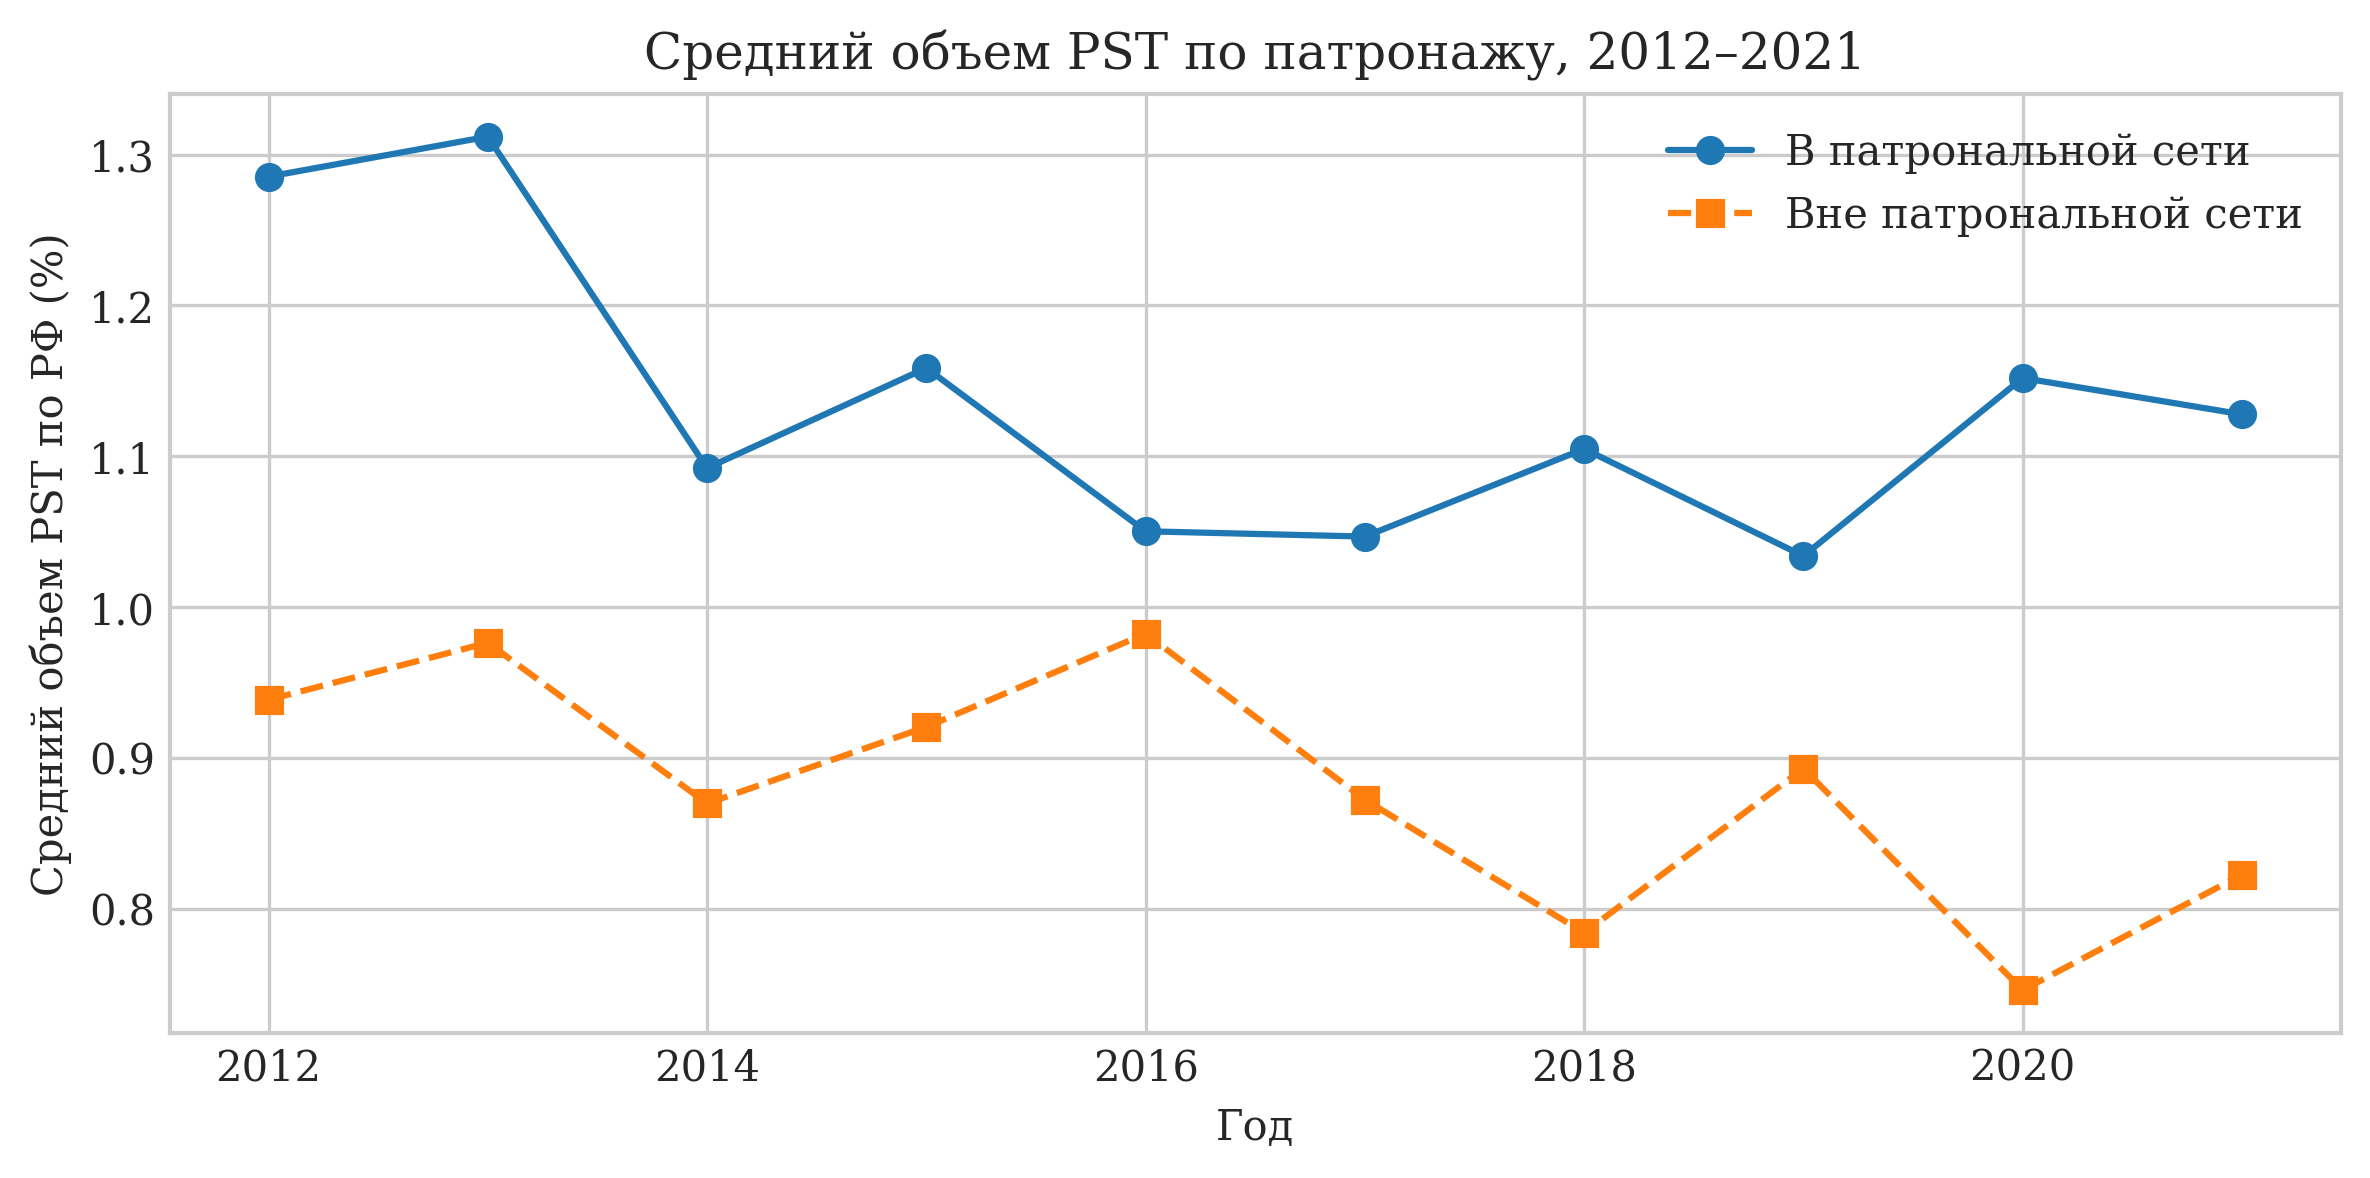

In [17]:
pat_means = y2.groupby(['year', 'patronaged'])['PST'].mean().unstack()
pat_means.columns = ['Вне патрональной сети', 'В патрональной сети']

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(pat_means.index, pat_means['В патрональной сети'],
        marker='o', label='В патрональной сети')
ax.plot(pat_means.index, pat_means['Вне патрональной сети'],
        marker='s', ls='--', label='Вне патрональной сети')

ax.set_xlabel('Год')
ax.set_ylabel('Средний объем PST по РФ (%)')
ax.set_title('Средний объем PST по патронажу, 2012–2021')
ax.legend()

plt.tight_layout()
plt.show()

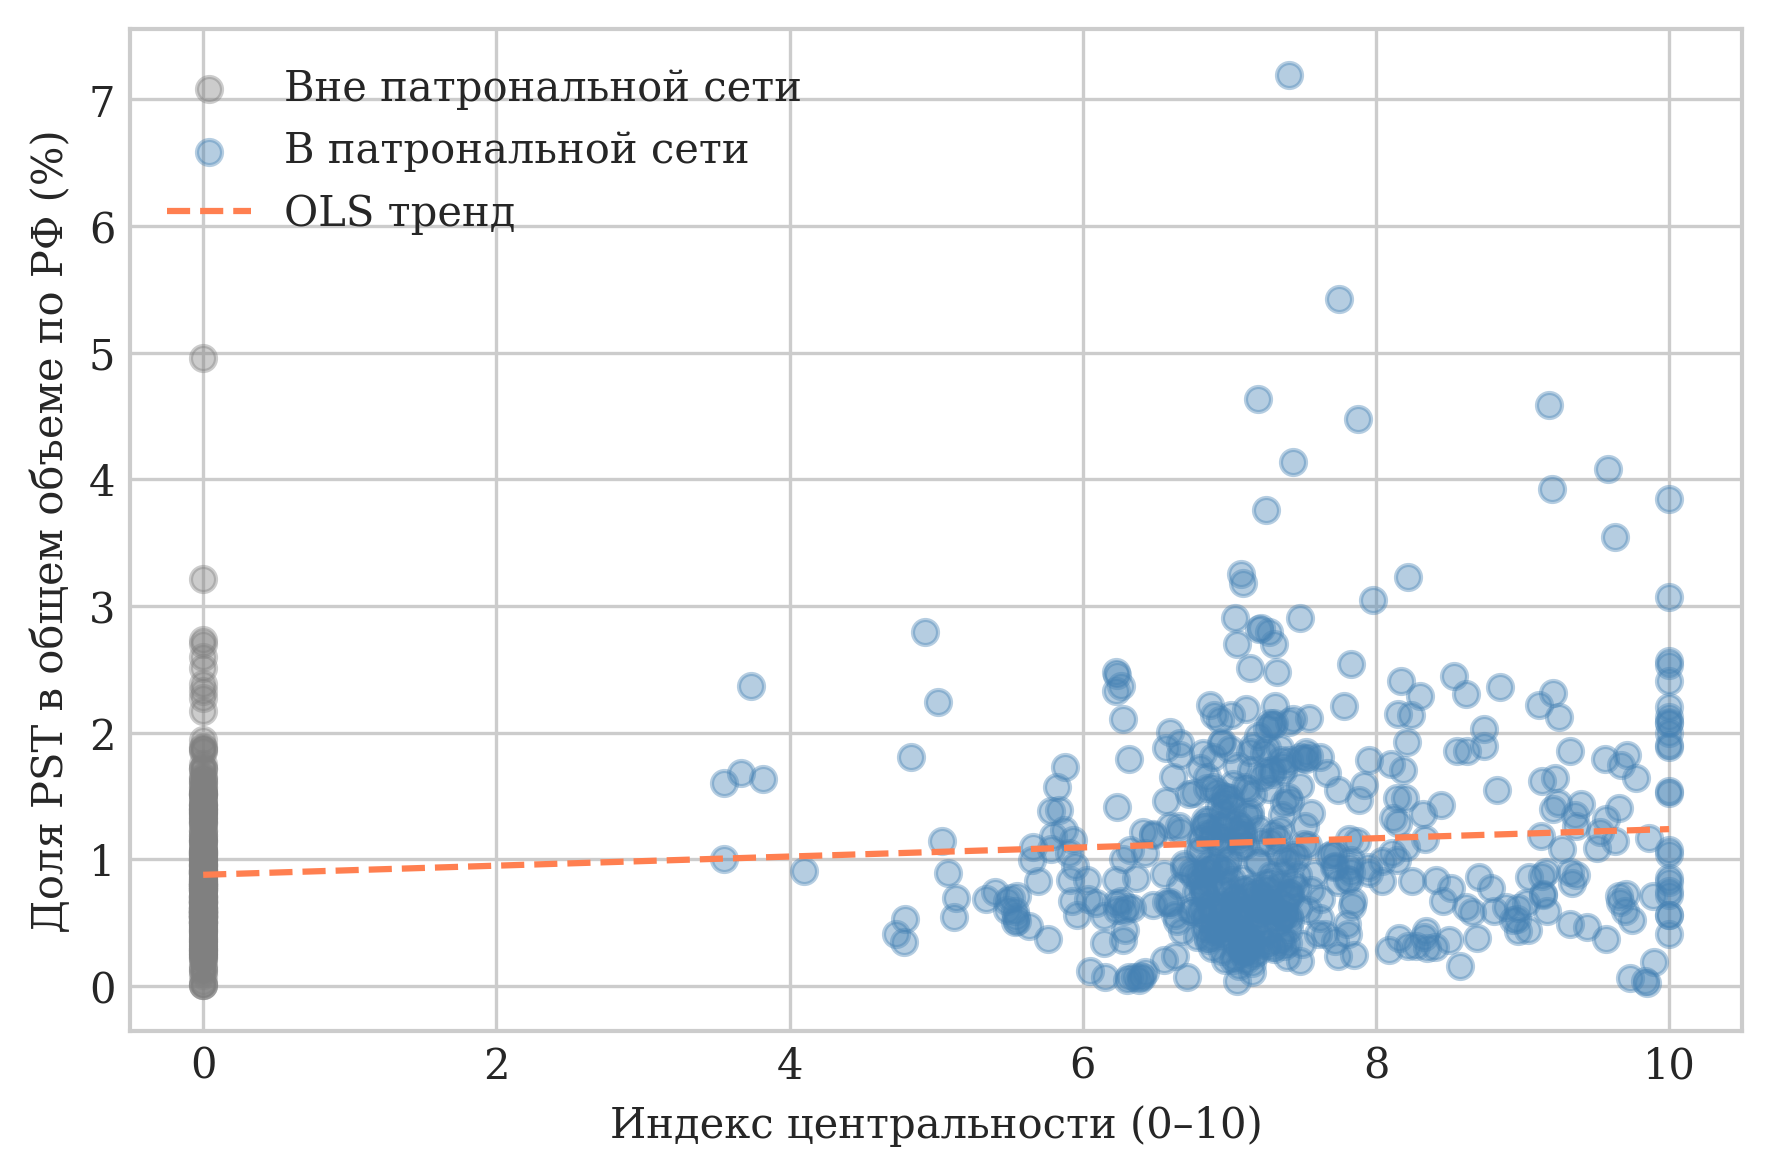

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

for pat, label, color, marker in [
    (0, 'Вне патрональной сети', 'gray', 'o'),
    (1, 'В патрональной сети', 'steelblue', 'o'),]:
    subset = y2[y2['patronaged'] == pat]
    ax.scatter(subset['closeness_centr'], subset['PST'],
               alpha=0.4, label=label, color=color, marker=marker)

# Линия тренда (pooled OLS)
xfit = np.linspace(y2['closeness_centr'].min(), y2['closeness_centr'].max(), 200)
poly = np.polyfit(y2['closeness_centr'], y2['PST'], 1)
ax.plot(xfit, np.polyval(poly, xfit), color='coral', ls='--', label='OLS тренд')

ax.set_xlabel('Индекс центральности (0–10)')
ax.set_ylabel('Доля PST в общем объеме по РФ (%)')
ax.legend()

plt.tight_layout()
plt.show()

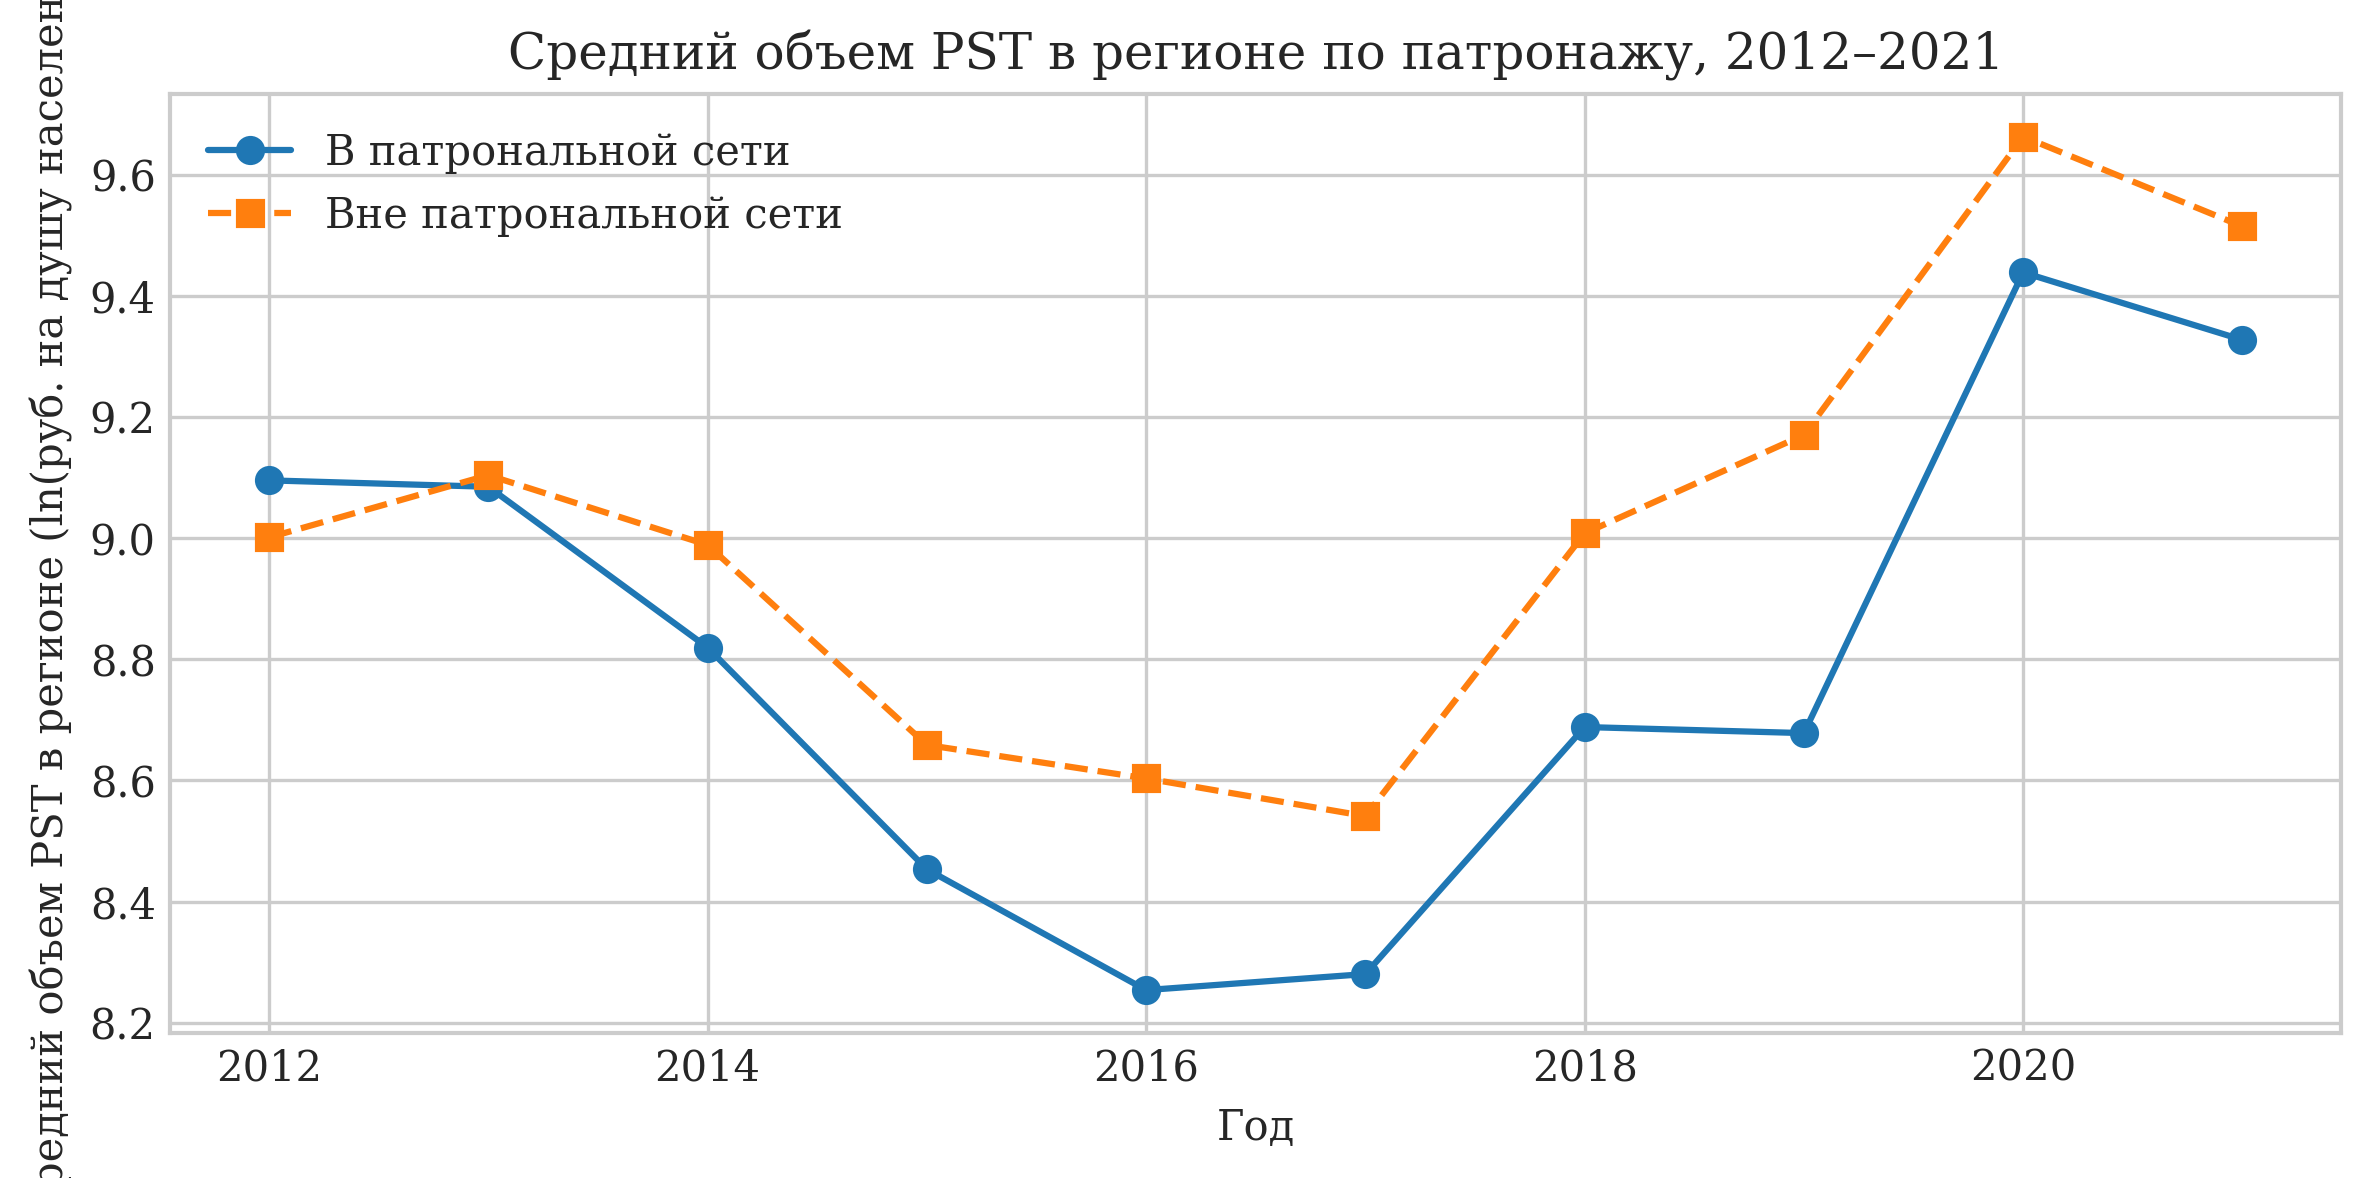

In [19]:
pat_means = y3.groupby(['year', 'patronaged'])['ln_PST'].mean().unstack()
pat_means.columns = ['Вне патрональной сети', 'В патрональной сети']

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(pat_means.index, pat_means['В патрональной сети'],
        marker='o', label='В патрональной сети')
ax.plot(pat_means.index, pat_means['Вне патрональной сети'],
        marker='s', ls='--', label='Вне патрональной сети')

ax.set_xlabel('Год')
ax.set_ylabel('Средний объем PST в регионе (ln(руб. на душу населения))')
ax.set_title('Средний объем PST в регионе по патронажу, 2012–2021')
ax.legend()

plt.tight_layout()
plt.show()

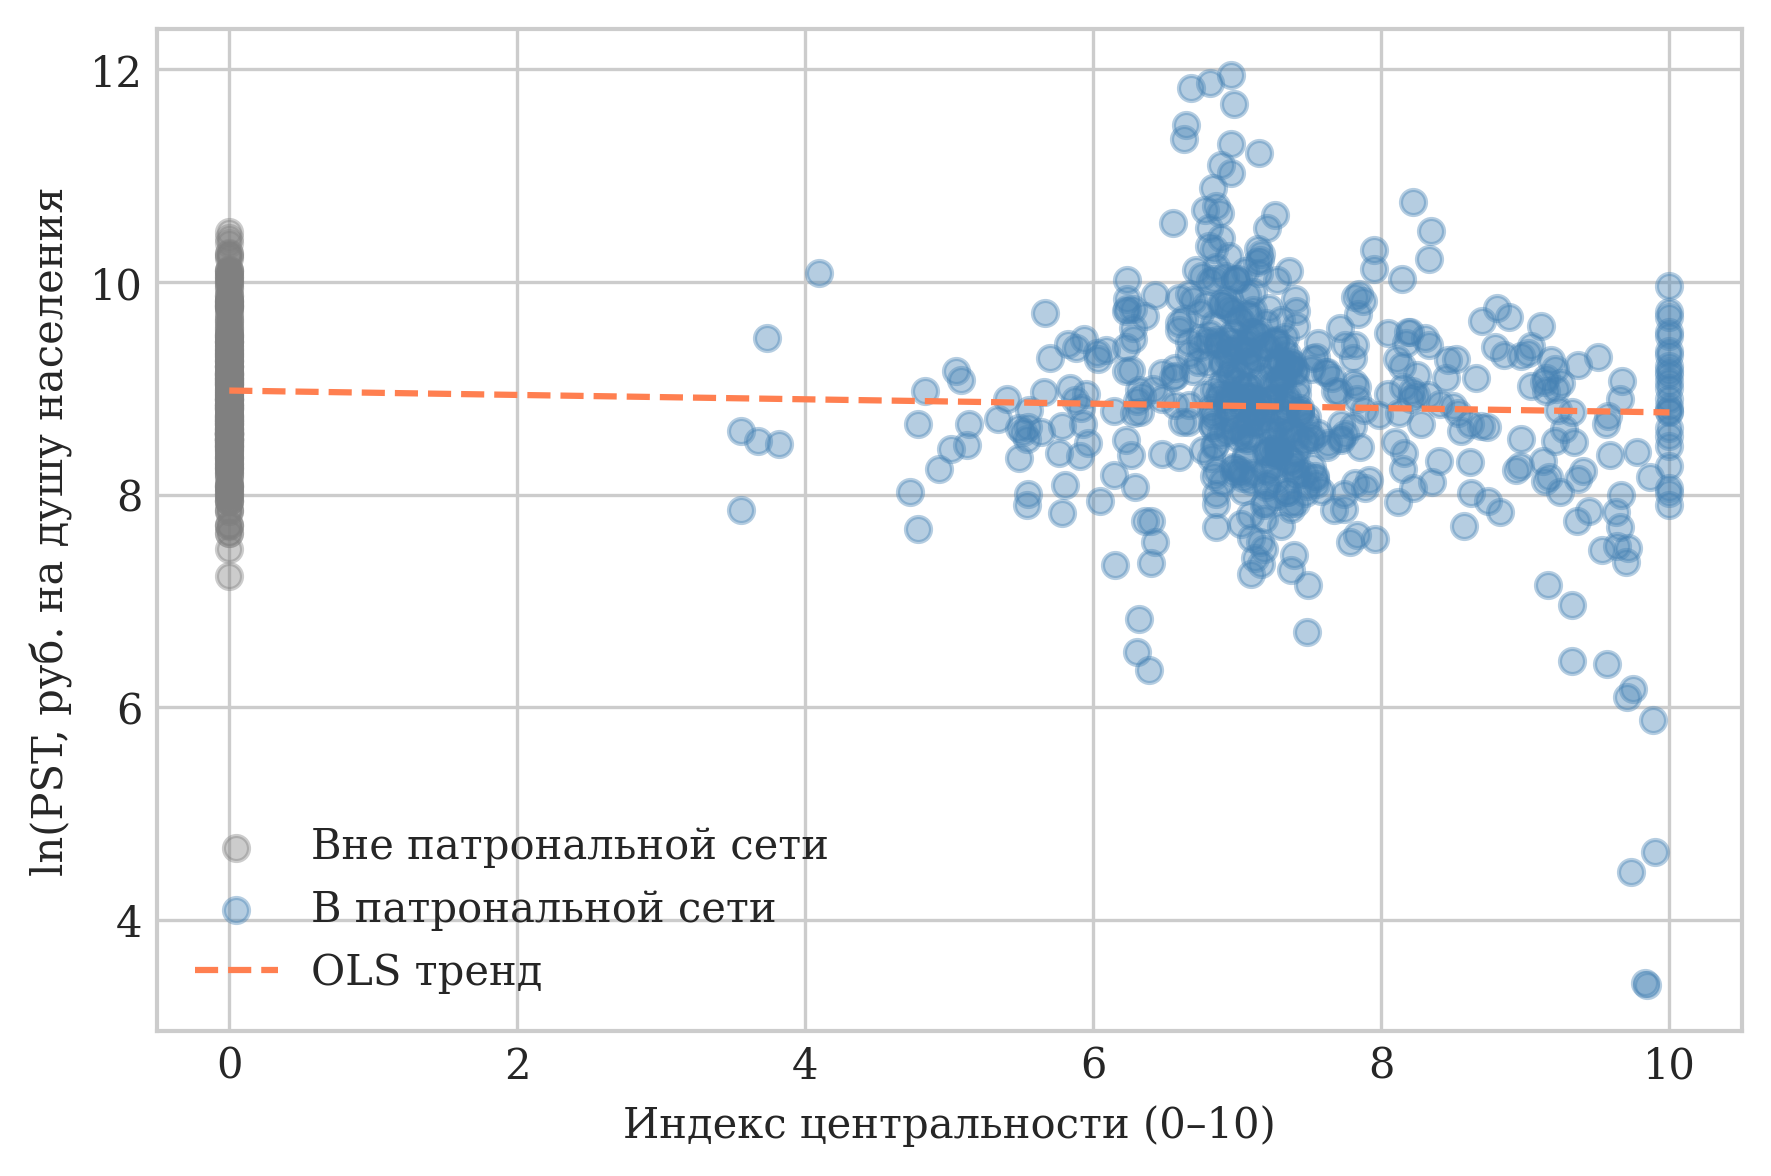

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))

for pat, label, color, marker in [
    (0, 'Вне патрональной сети', 'gray', 'o'),
    (1, 'В патрональной сети', 'steelblue', 'o'),]:
    subset = y3[y3['patronaged'] == pat]
    ax.scatter(subset['closeness_centr'], subset['ln_PST'],
               alpha=0.4, label=label, color=color, marker=marker)

# Линия тренда (pooled OLS)
xfit = np.linspace(y3['closeness_centr'].min(), y3['closeness_centr'].max(), 200)
poly = np.polyfit(y3['closeness_centr'], y3['ln_PST'], 1)
ax.plot(xfit, np.polyval(poly, xfit), color='coral', ls='--', label='OLS тренд')

ax.set_xlabel('Индекс центральности (0–10)')
ax.set_ylabel('ln(PST, руб. на душу населения')
ax.legend()

plt.tight_layout()
plt.show()

<a id="section-1-3"></a>
### 1.3 Распределение политически чувствительных трансфертов – подходы к измерению (Y2, Y3)

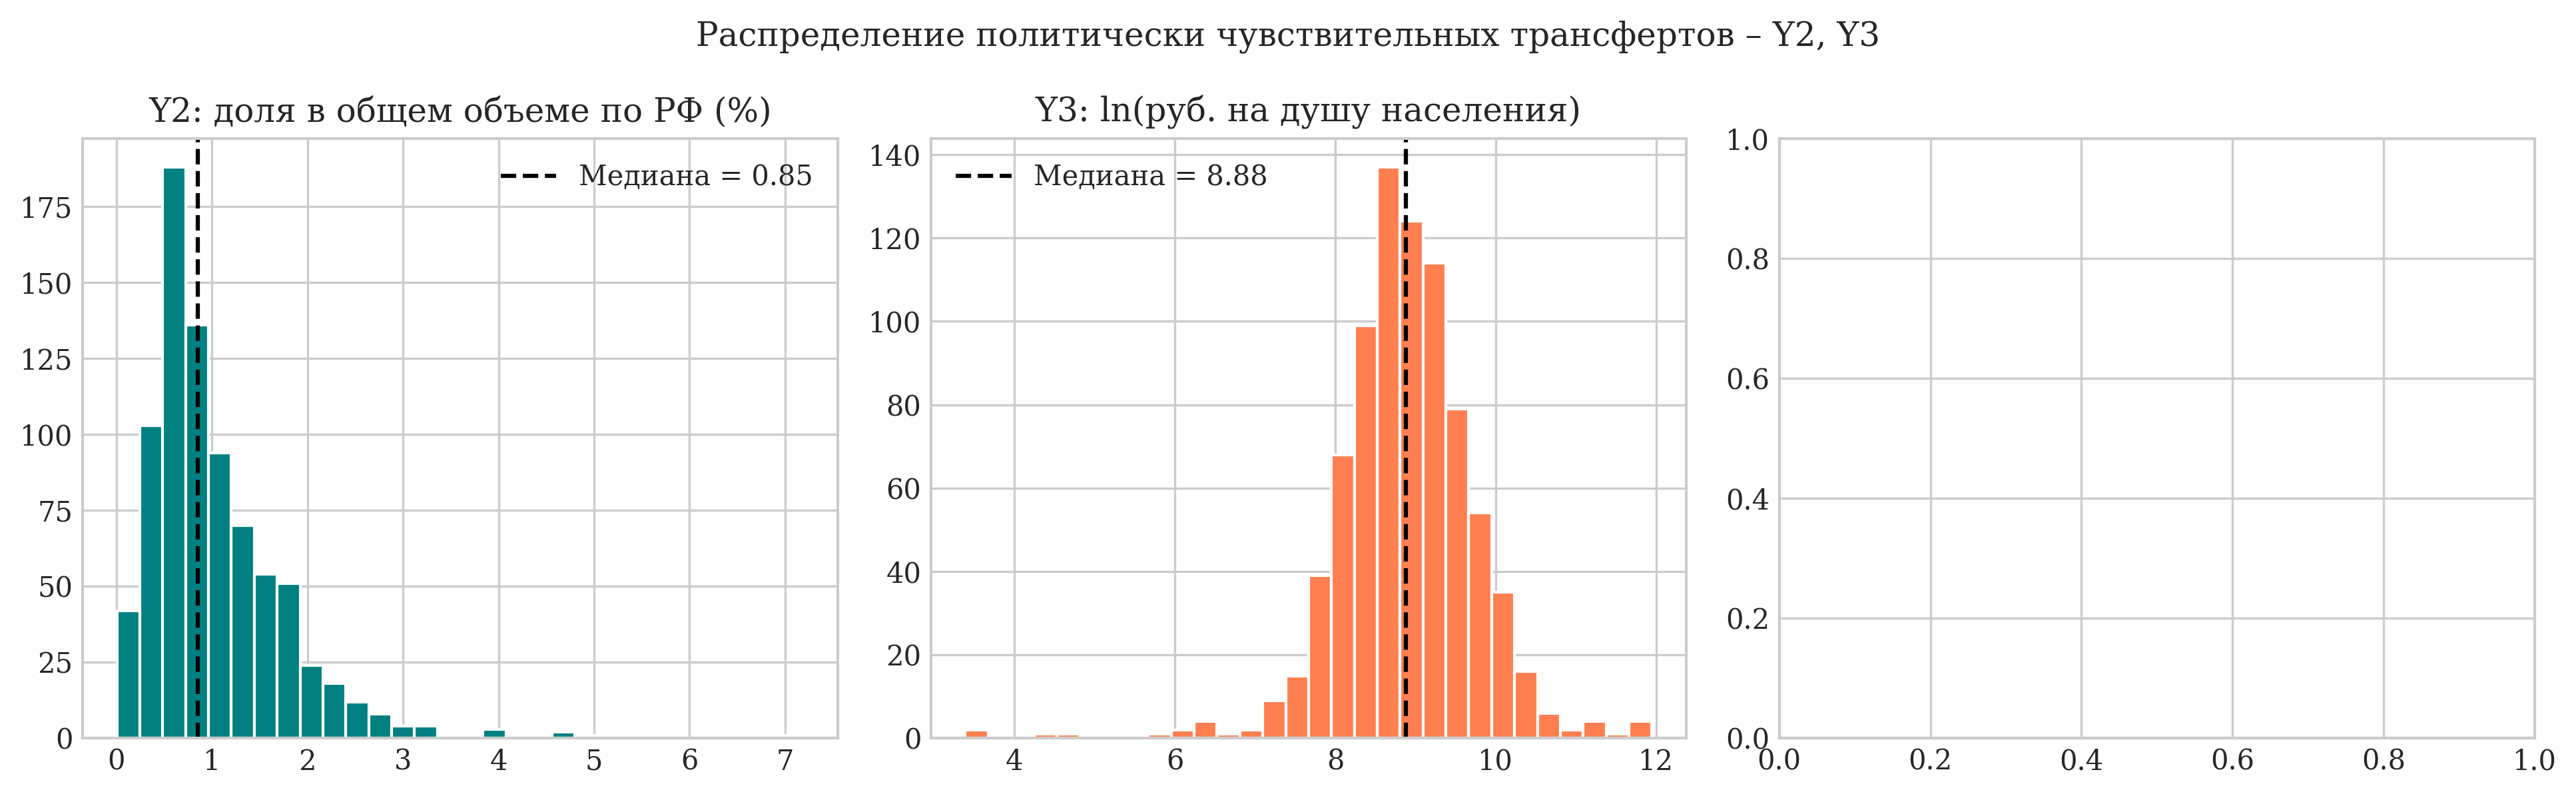

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Распределение политически чувствительных трансфертов – Y2, Y3')

panels = [
    (y2['PST'], 'Y2: доля в общем объеме по РФ (%)', 'teal'),
    (y3['ln_PST'], 'Y3: ln(руб. на душу населения)', 'coral'),]

for ax, (data, title, color) in zip(axes, panels):
    ax.hist(data.dropna(), bins=30, color=color, edgecolor='white')
    ax.axvline(data.median(), color='black', ls='--',
               label=f'Медиана = {data.median():.2f}')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()
# plt.savefig('fig01_PST_distributions.png', dpi=150, bbox_inches='tight')

> **Комментарий**: В распределении Y2 присутствует правосторонняя асимметрия, что говорит о наличии группы регионов, получающих больше трансфертов. По Y3 распределение после логарифмирования приближено к нормальному. Есть нетипично высокие значения и нетипично малые.

<a id="section-1-4"></a>
### 1.4 Динамика индекса центральности в патрональной сети по годам

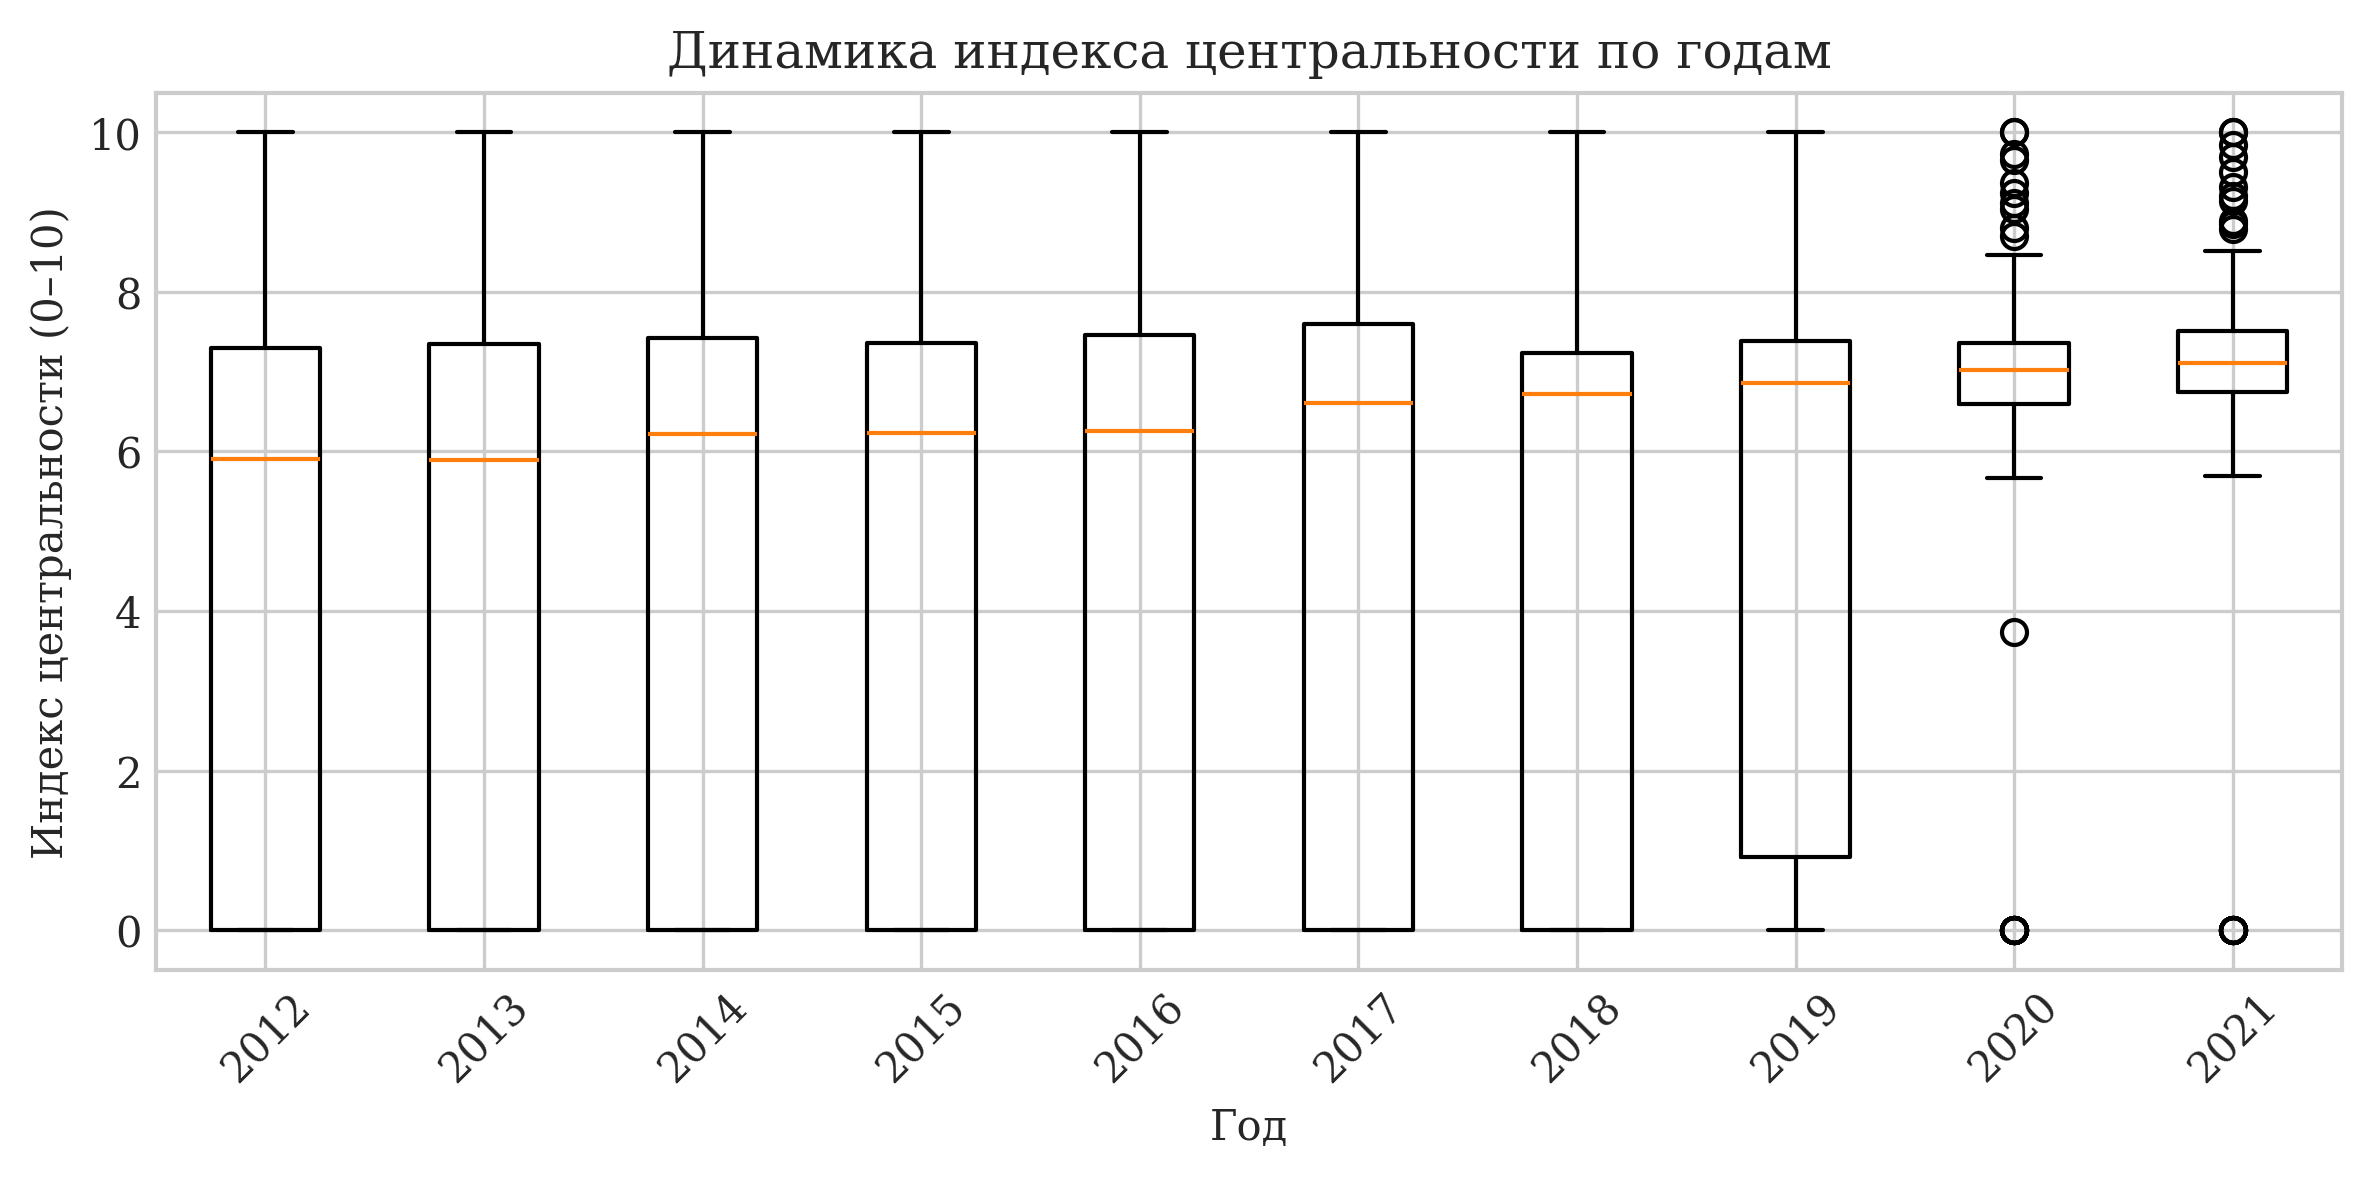

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

plot_data = [y2[y2['year'] == yr]['closeness_centr'].dropna().values
             for yr in range(2012, 2022)]
ax.boxplot(plot_data, tick_labels=range(2012, 2022))
ax.set_xticklabels(range(2012, 2022), rotation=45)
ax.set_xlabel('Год')
ax.set_ylabel('Индекс центральности (0–10)')
ax.set_title('Динамика индекса центральности по годам')

plt.tight_layout()
plt.show()

<a id="section-1-5"></a>
### 1.5 Ранжирование регионов по среднему объему политически чувствительных трнсфертов

**Топ-10 по среднему объему PST (%)**

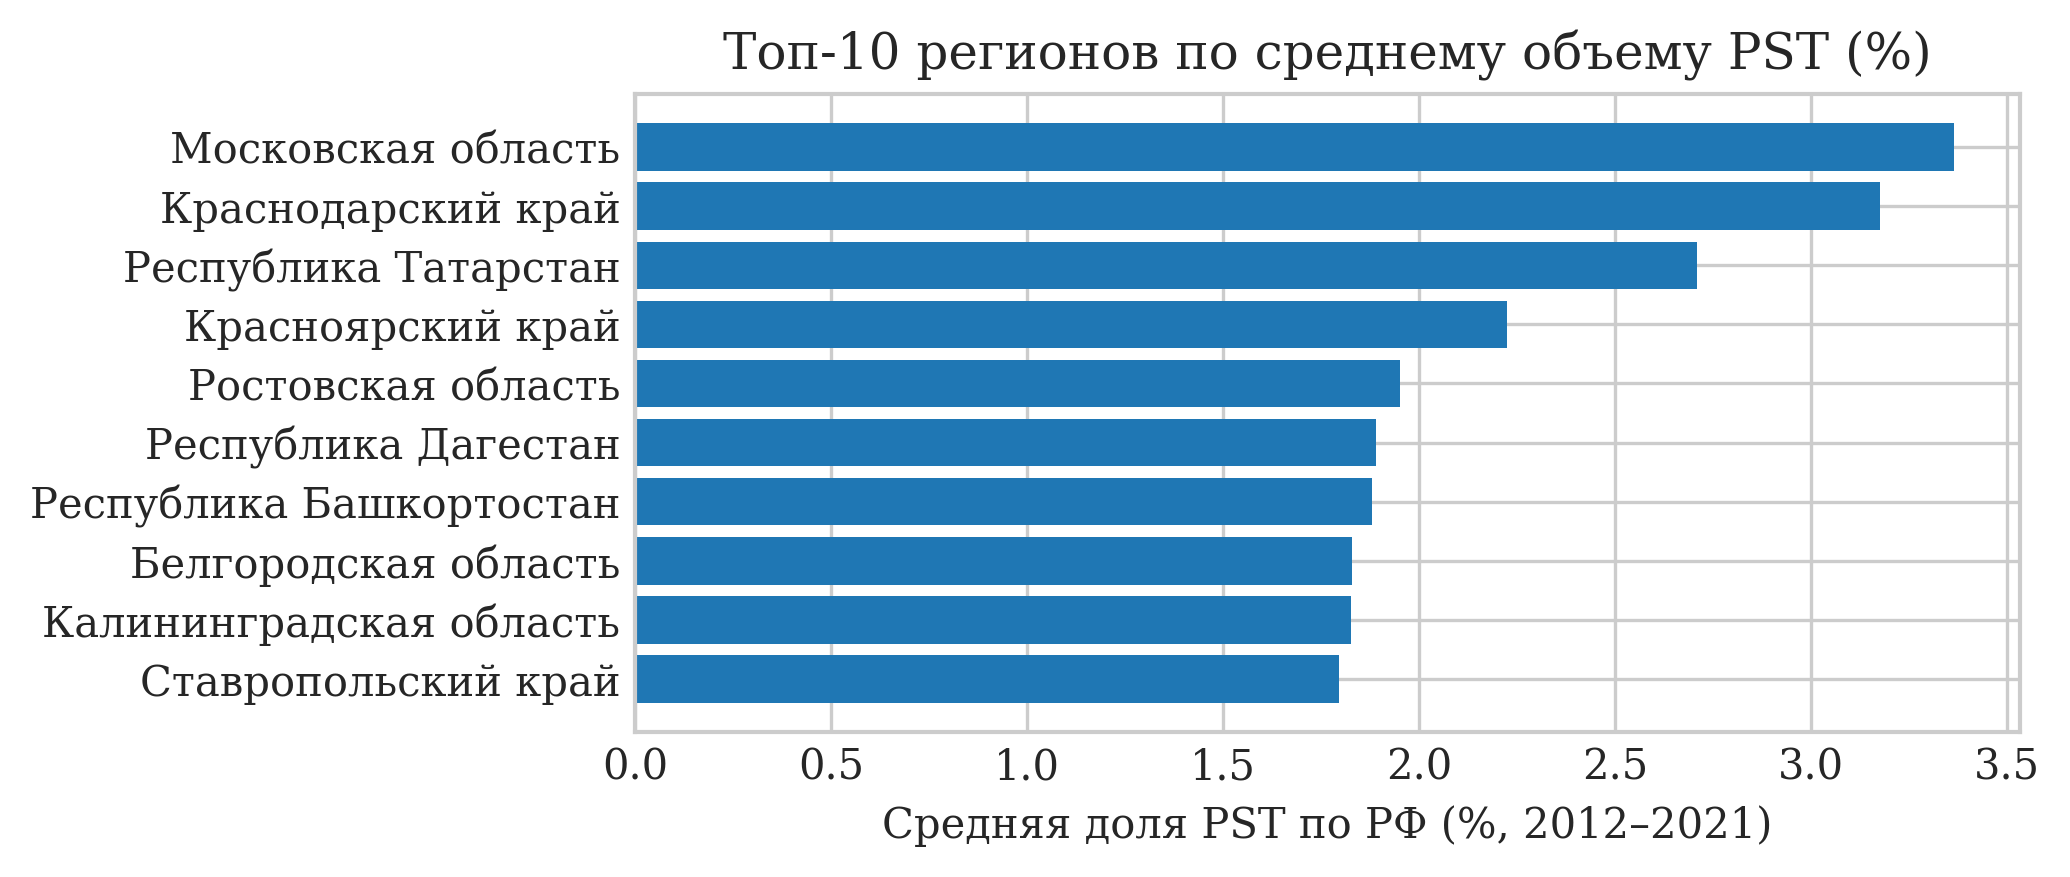

In [23]:
top10 = y2.groupby('region_name')['PST'].mean().nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(top10.index, top10.values)
ax.set_xlabel('Средняя доля PST по РФ (%, 2012–2021)')
ax.set_title('Топ-10 регионов по среднему объему PST (%)')

plt.tight_layout()
plt.show()

**Рейтинг по среднему объему PST (%)**

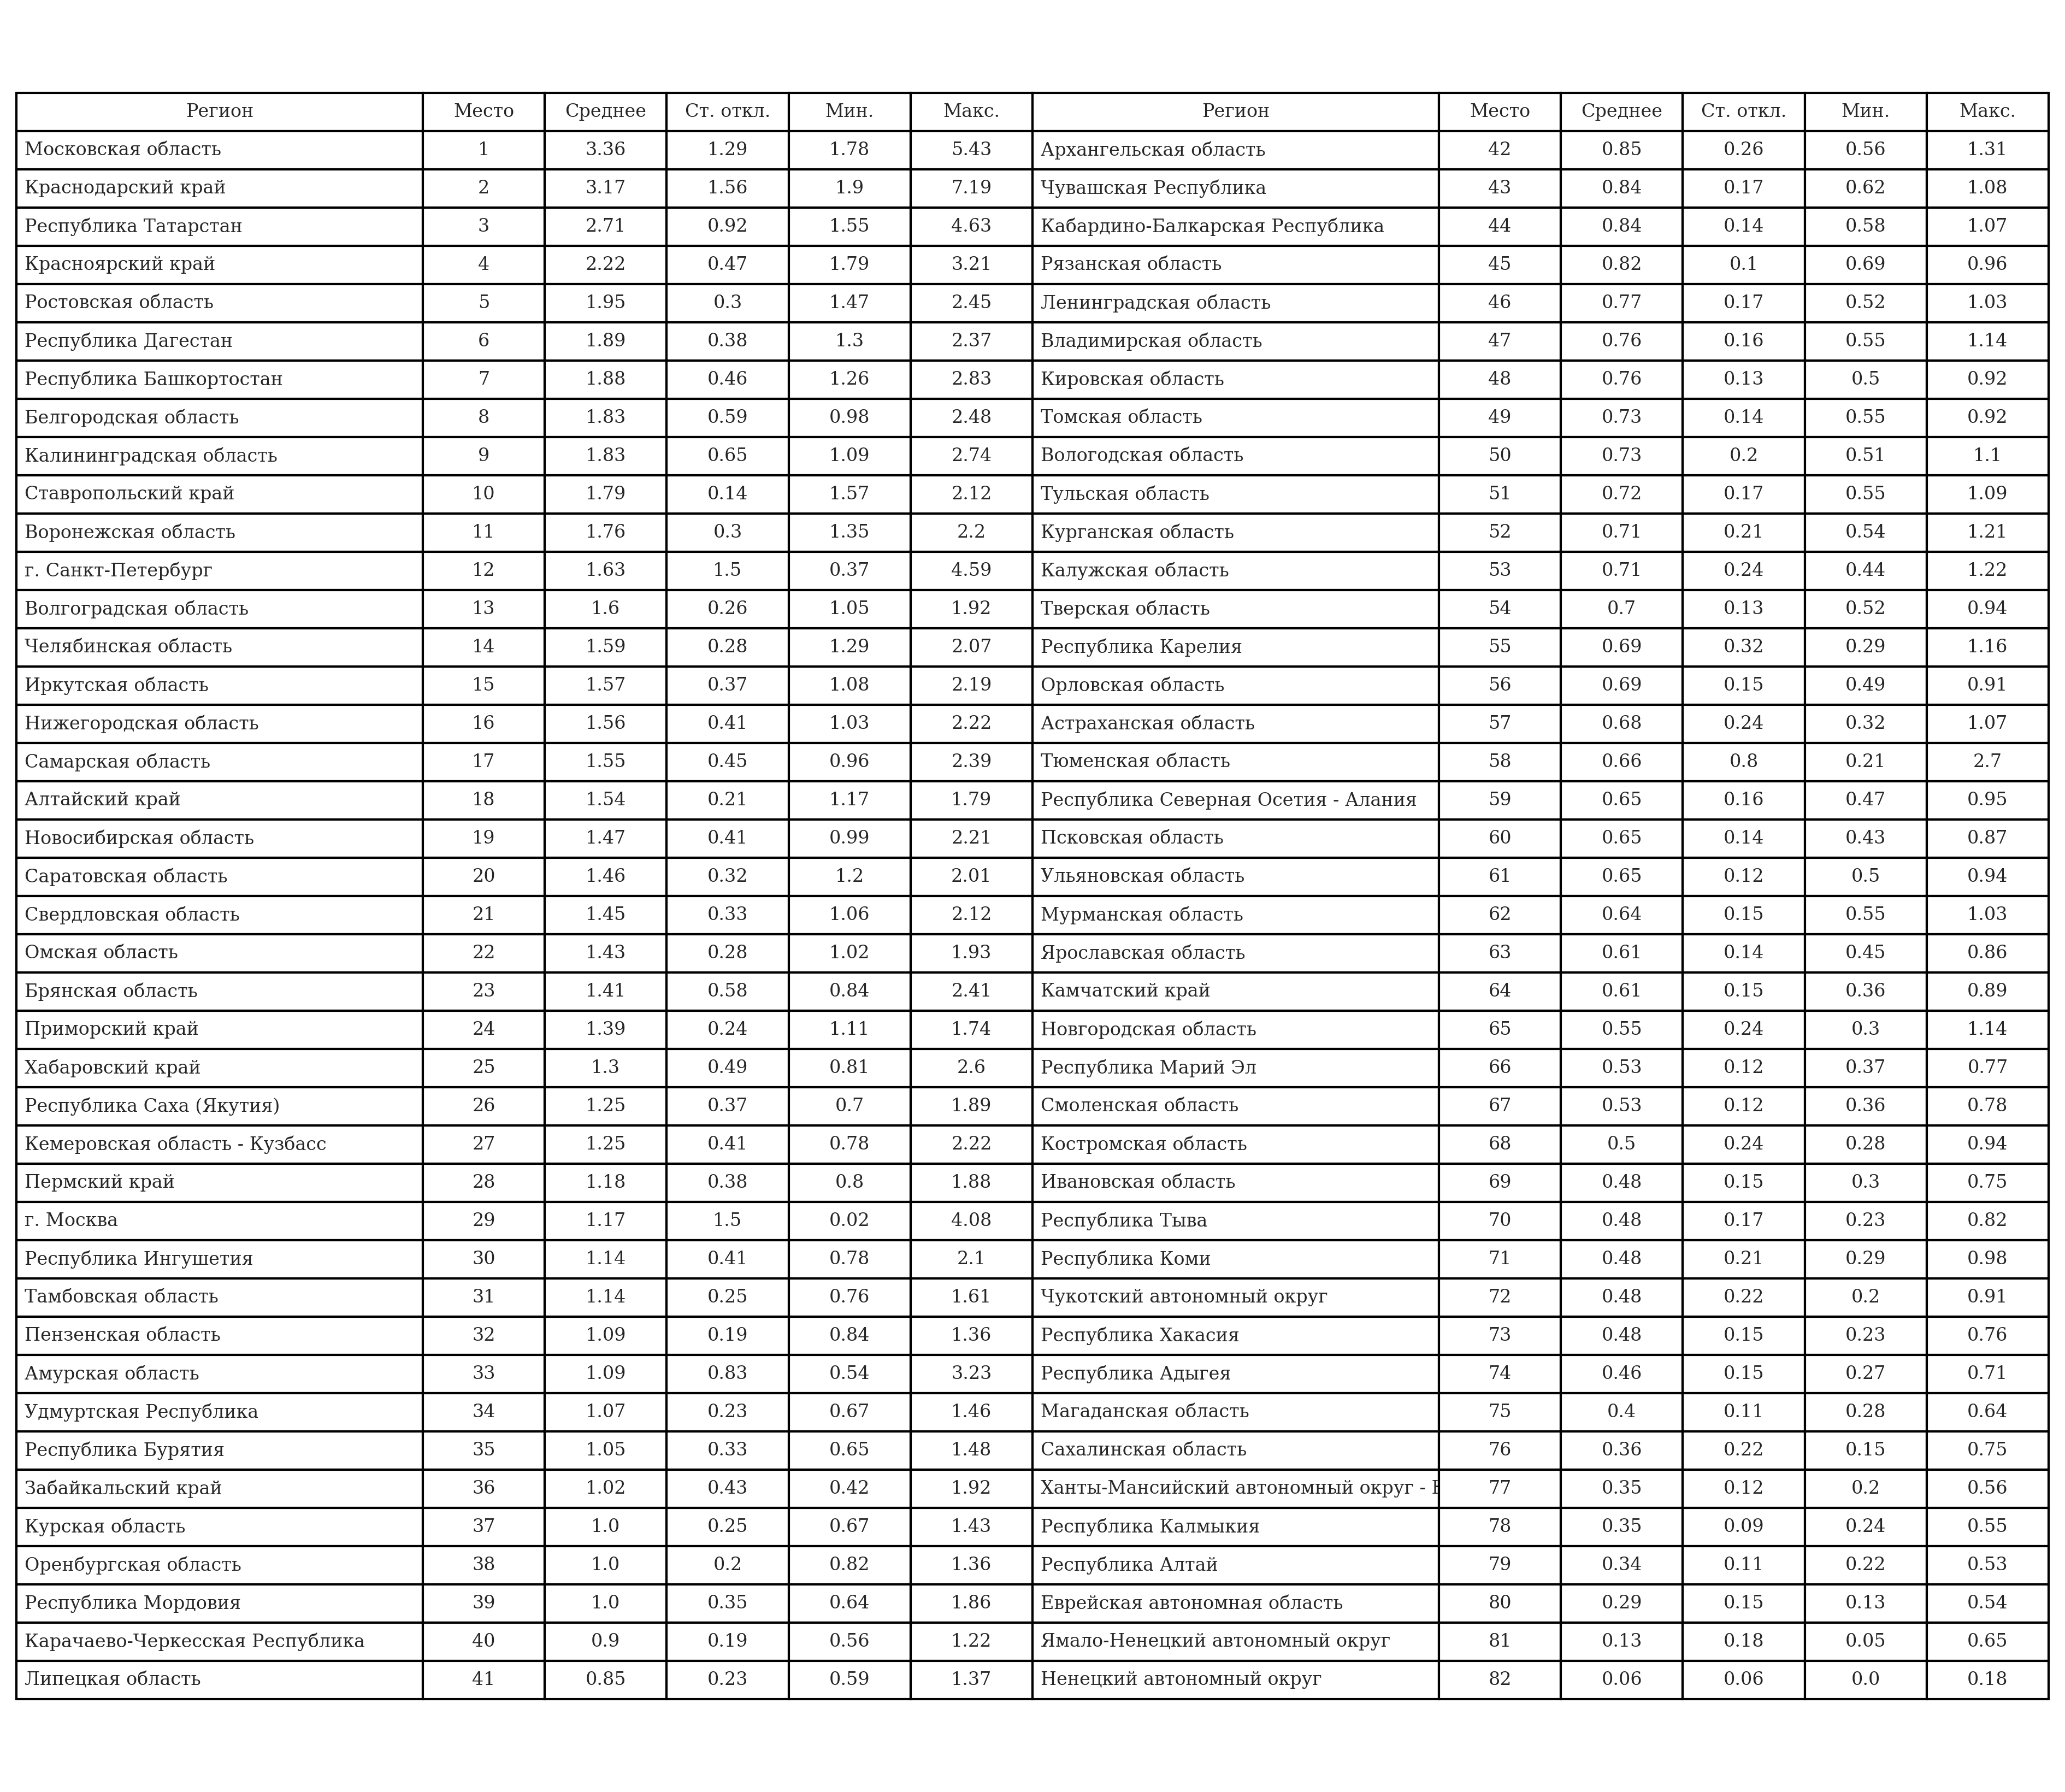

In [24]:
ranking1 = (
    y2.groupby('region_name')['PST']
    .agg(['mean', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
)
ranking1.columns = ['Среднее', 'Ст. откл.', 'Мин.', 'Макс.']
ranking1.index.name = 'Регион'
ranking1 = ranking1.round(2)
ranking1.insert(0, 'Место', range(1, len(ranking1) + 1))

half = (len(ranking1) + 1) // 2
left = ranking1.reset_index().iloc[:half].reset_index(drop=True)
right = ranking1.reset_index().iloc[half:].reset_index(drop=True)

if len(right) < len(left):
    pad = pd.DataFrame([['']*len(left.columns)], columns=left.columns)
    right = pd.concat([right, pad], ignore_index=True)

two_col = pd.concat([left, right], axis=1)

fig, ax = plt.subplots(figsize=(16, half * 0.34))
ax.axis('off')
tbl = ax.table(cellText=two_col.values,
               colLabels=two_col.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.4)

region_cols = [0, len(left.columns)]
for (row, col), cell in tbl.get_celld().items():
    if col in region_cols:
        cell.set_width(0.20)
        if row > 0:
            cell.get_text().set_ha('left')
            cell.PAD = 0.02
    else:
        cell.set_width(0.06)
plt.show()

**Топ-10 по среднему объему PST (руб. на душу населения)**

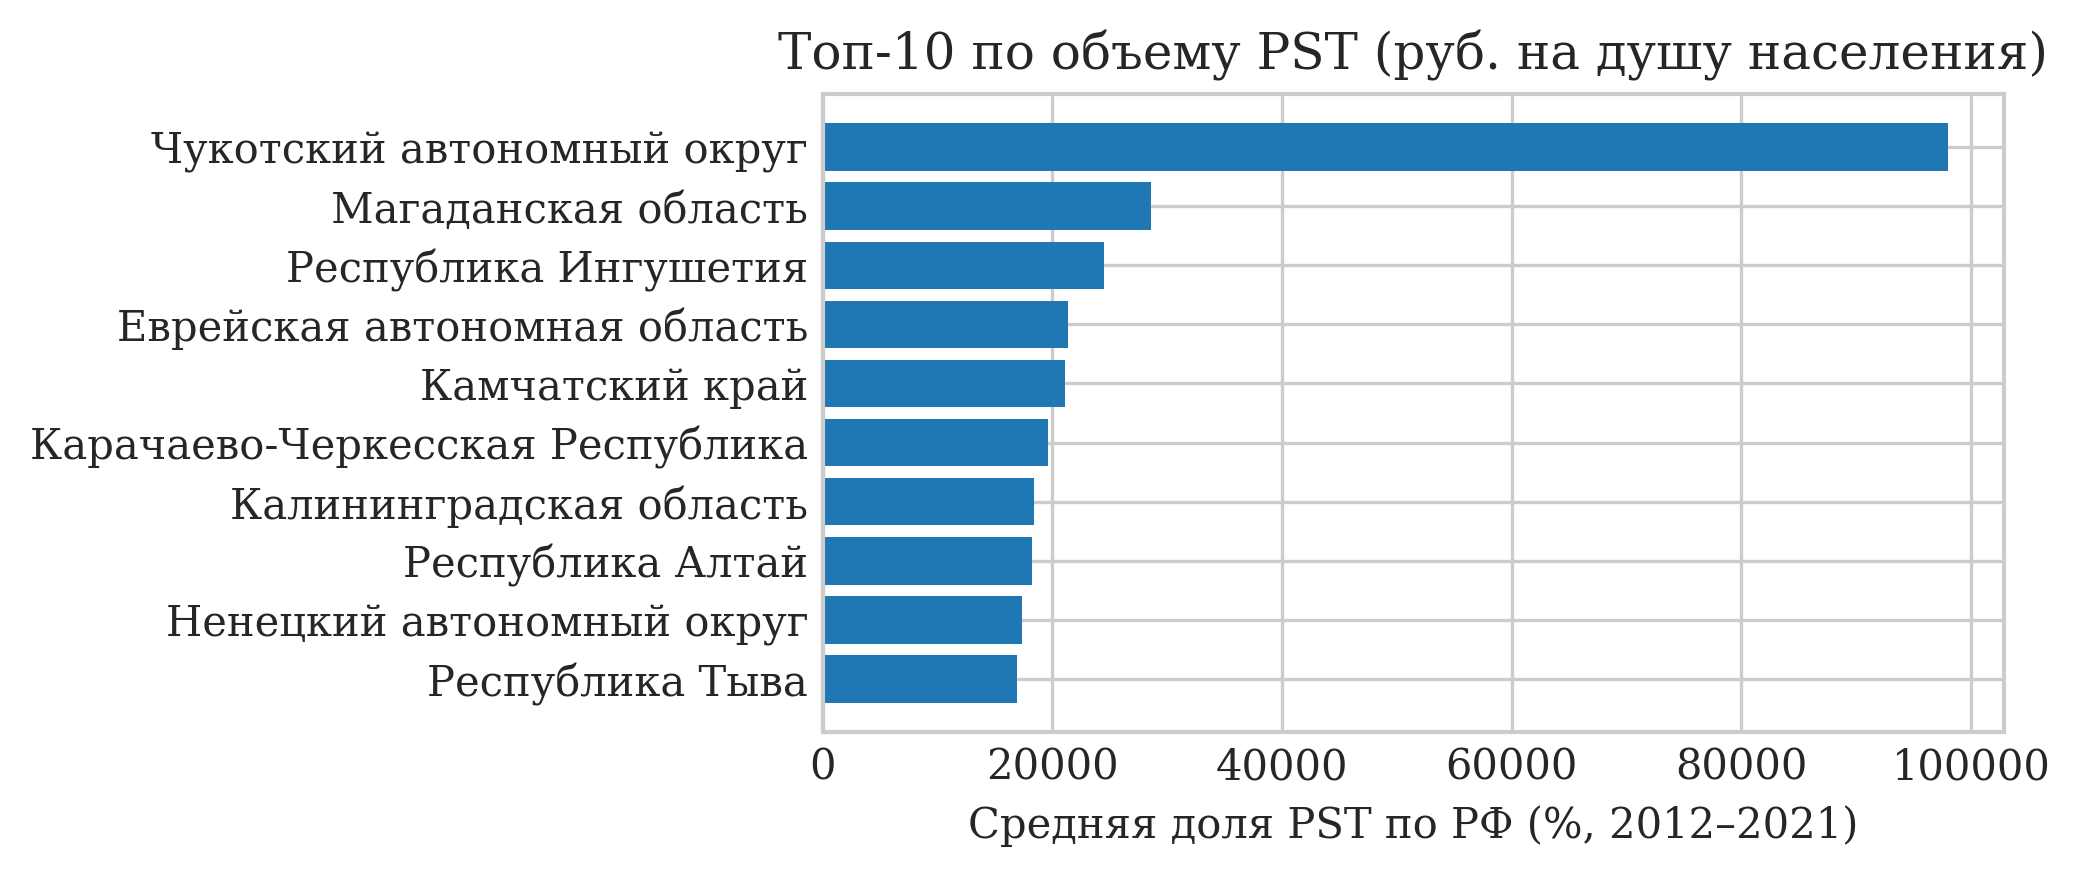

In [25]:
top10 = y3.groupby('region_name')['PST'].mean().nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(top10.index, top10.values)
ax.set_xlabel('Средняя доля PST по РФ (%, 2012–2021)')
ax.set_title('Топ-10 по объему PST (руб. на душу населения)')

plt.tight_layout()
plt.show()

**Рейтинг по среднему объему PST (руб. на душу населения)**

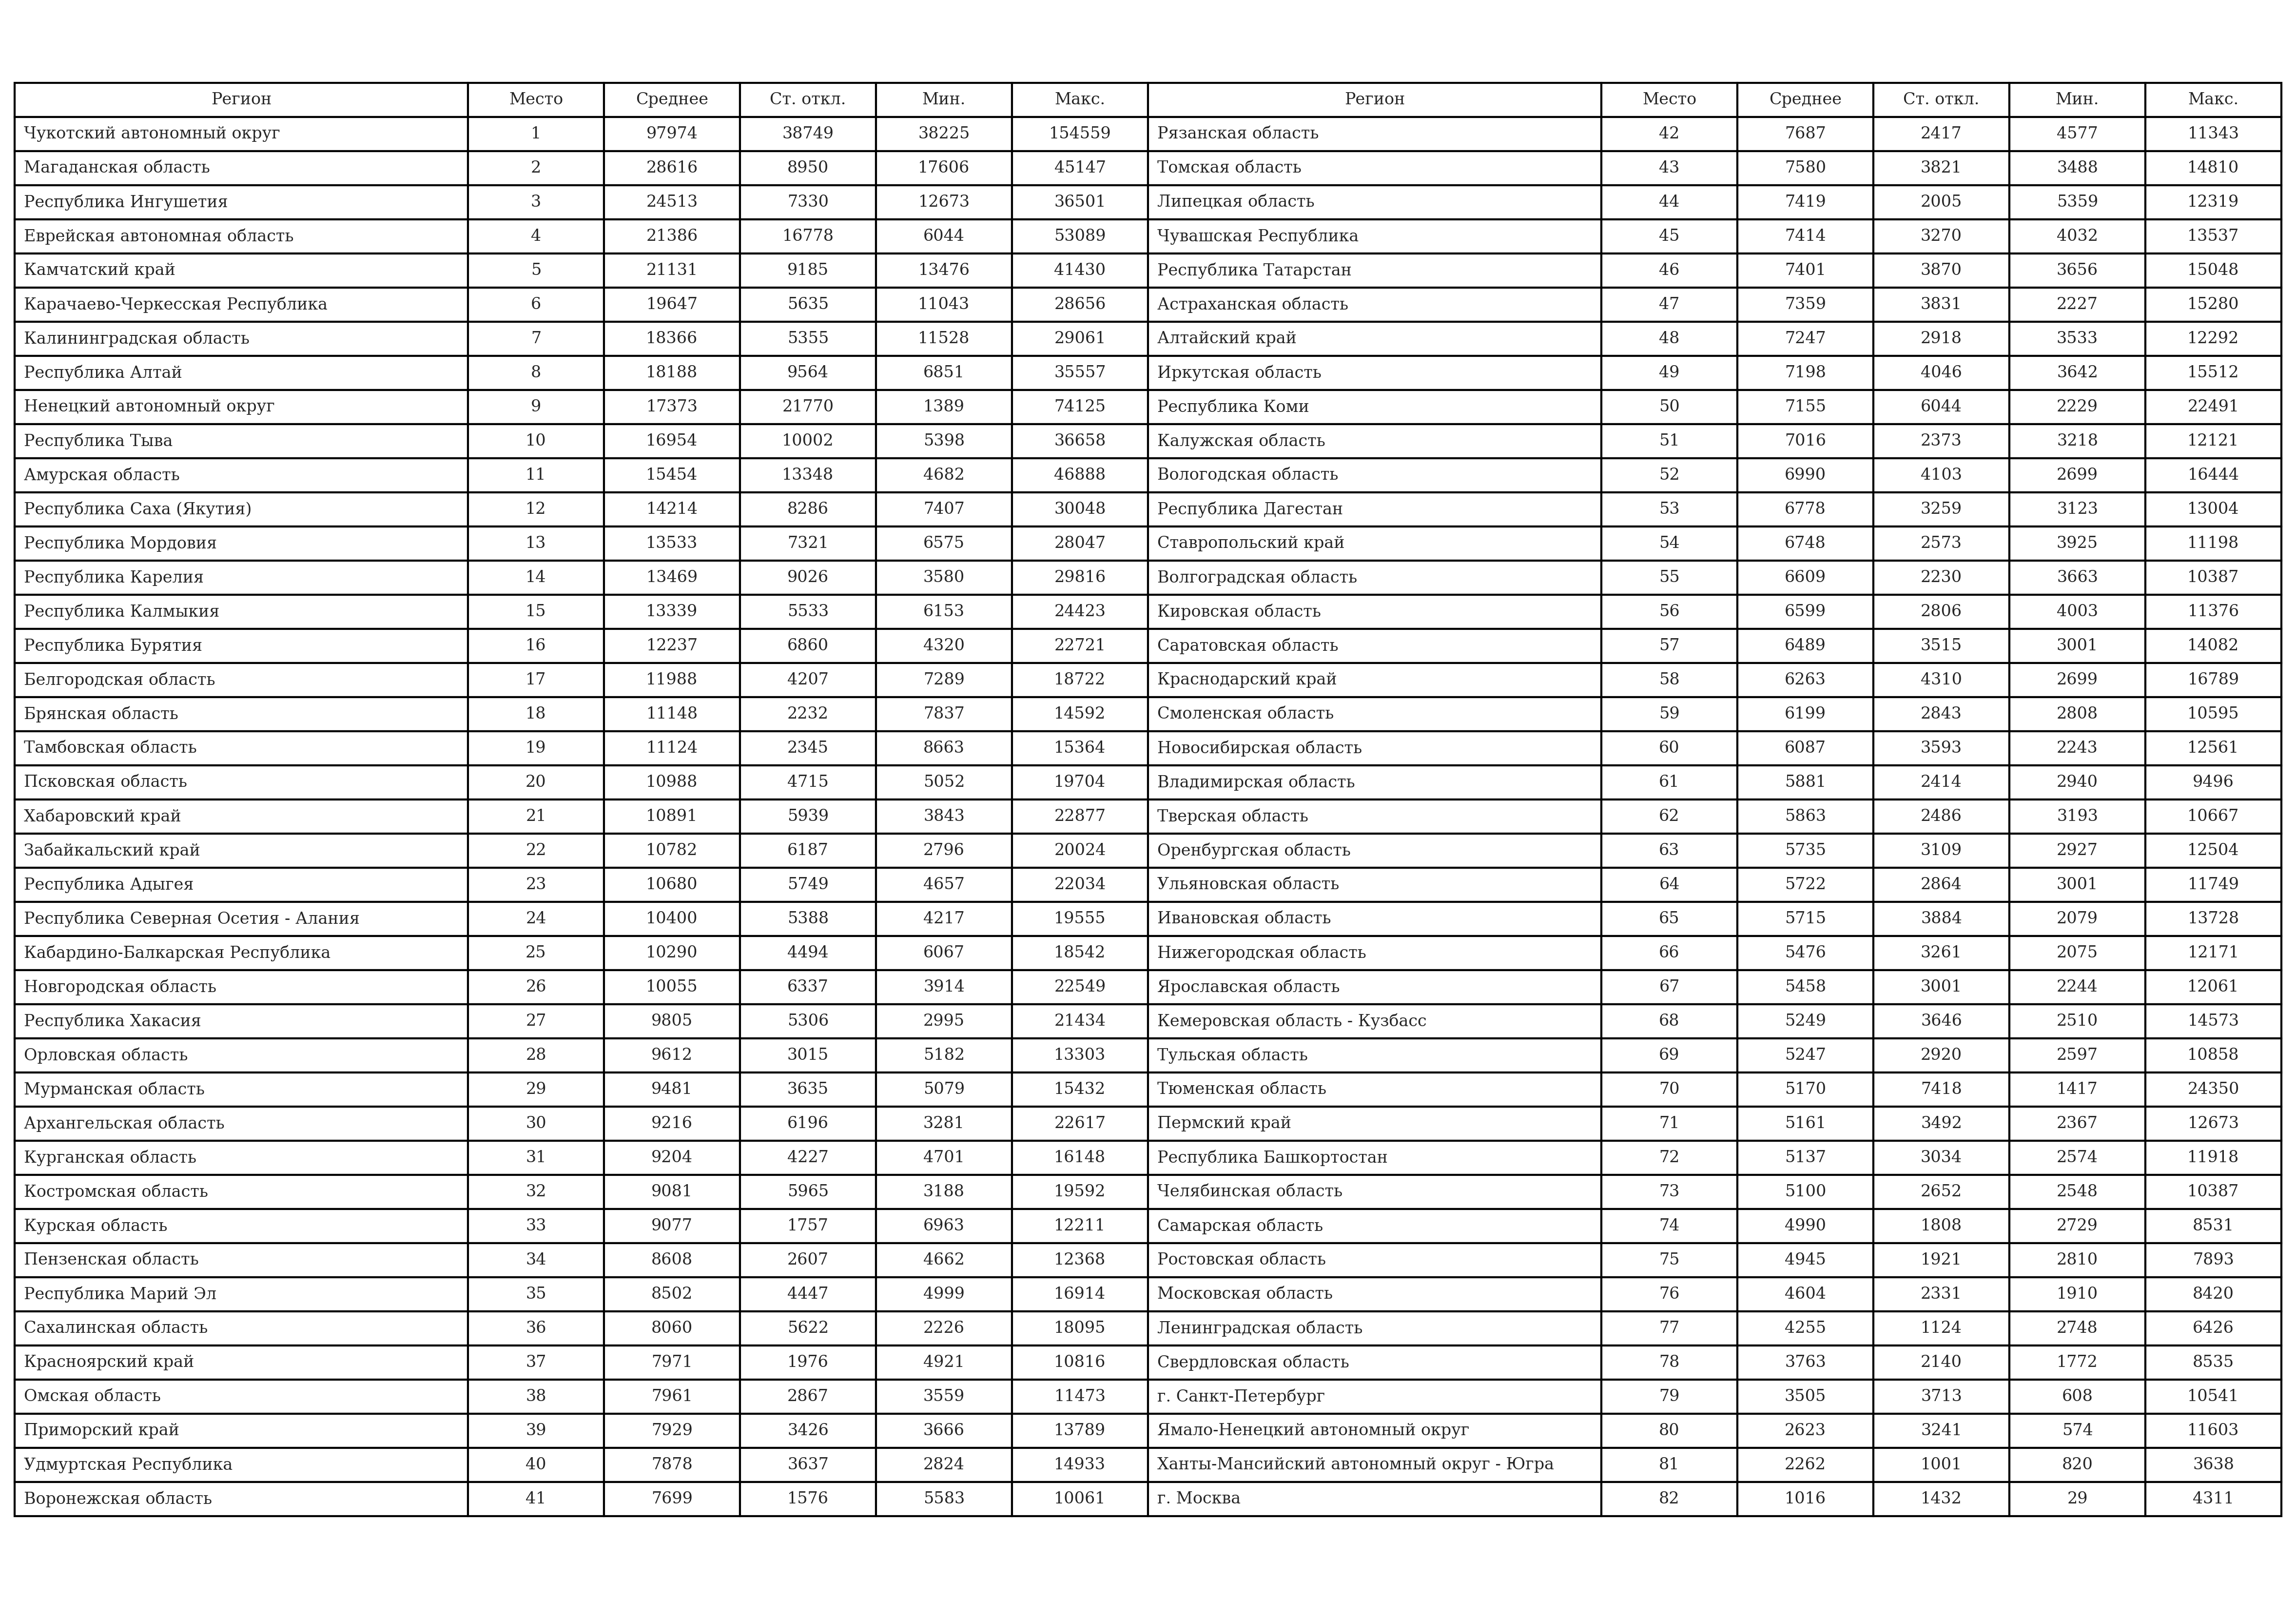

In [26]:
ranking = (
    y3.groupby('region_name')['PST']
    .agg(['mean', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
)
ranking.columns = ['Среднее', 'Ст. откл.', 'Мин.', 'Макс.']
ranking.index.name = 'Регион'
ranking = ranking.round(0).astype(int)
ranking.insert(0, 'Место', range(1, len(ranking) + 1))

half = (len(ranking) + 1) // 2
left = ranking.reset_index().iloc[:half].reset_index(drop=True)
right = ranking.reset_index().iloc[half:].reset_index(drop=True)
if len(right) < len(left):
    pad = pd.DataFrame([['']*len(left.columns)], columns=left.columns)
    right = pd.concat([right, pad], ignore_index=True)
two_col = pd.concat([left, right], axis=1)

fig, ax = plt.subplots(figsize=(20, half * 0.34))
ax.axis('off')
tbl = ax.table(cellText=two_col.values, colLabels=two_col.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.4)

region_cols = [0, len(left.columns)]          # «Регион» теперь ПЕРВАЯ колонка
for (row, col), cell in tbl.get_celld().items():
    if col in region_cols:
        cell.set_width(0.20)
        if row > 0:
            cell.get_text().set_ha('left')
            cell.PAD = 0.02
    else:
        cell.set_width(0.06)

plt.show()

<a id="section-2"></a>
# 2. Диагностика мультиколлинеарности

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

<a id="section-2-1"></a>
### 2.1 Корреляционная матрица предикторов

In [28]:
controls = ['closeness_centr', 'patronaged', 't1',
             'ln_population', 'ln_grp_pc_L1', 'log_growth',
             'Urbanization', 'turnout', 'UR', 'Putin', 'russian_share']

y2[controls].corr().round(3)

,closeness_centr,patronaged,t1,ln_population,ln_grp_pc_L1,log_growth,Urbanization,turnout,UR,Putin,russian_share
closeness_centr,1.000,0.965,0.054,0.221,0.078,-0.023,0.107,-0.085,-0.005,0.117,0.117
patronaged,0.965,1.000,0.068,0.169,0.081,-0.033,0.080,-0.044,0.031,0.155,0.079
t1,0.054,0.068,1.000,-0.009,0.013,0.009,0.031,-0.064,-0.063,-0.045,0.033
ln_population,0.221,0.169,-0.009,1.000,-0.175,-0.047,0.270,-0.104,-0.100,-0.077,0.257
ln_grp_pc_L1,0.078,0.081,0.013,-0.175,1.000,-0.026,0.557,-0.230,-0.252,-0.150,0.178
log_growth,-0.023,-0.033,0.009,-0.047,-0.026,1.000,0.030,-0.065,-0.000,0.018,0.084
Urbanization,0.107,0.080,0.031,0.270,0.557,0.030,1.000,-0.431,-0.486,-0.371,0.542
turnout,-0.085,-0.044,-0.064,-0.104,-0.230,-0.065,-0.431,1.000,0.786,0.477,-0.658
UR,-0.005,0.031,-0.063,-0.100,-0.252,-0.000,-0.486,0.786,1.000,0.765,-0.682
Putin,0.117,0.155,-0.045,-0.077,-0.150,0.018,-0.371,0.477,0.765,1.000,-0.570


<a id="section-2-2"></a>
### 2.2 Выбор спецификаций

**Спецификация 1**

In [29]:
X1 = y2[['closeness_centr', 't1', 'ln_population', 'ln_grp_pc_L1', 'log_growth', 'russian_share']]

X1 = add_constant(X1)

vif_data1 = pd.DataFrame()
vif_data1['feature'] = X1.columns
vif_data1['VIF'] = [
    variance_inflation_factor(X1.values, i)
    for i in range(X1.shape[1])
]

print(vif_data1)

           feature         VIF
0            const  734.437200
1  closeness_centr    1.071899
2               t1    1.004540
3    ln_population    1.196615
4     ln_grp_pc_L1    1.108705
5       log_growth    1.016201
6    russian_share    1.149973


**Спецификация 2**

In [30]:
X2 = y2[['closeness_centr', 't1', 'ln_population', 'ln_grp_pc_L1', 'log_growth', 'russian_share', 'turnout']]
X2 = add_constant(X2)

vif_data2 = pd.DataFrame()
vif_data2['feature'] = X2.columns
vif_data2['VIF'] = [
    variance_inflation_factor(X2.values, i)
    for i in range(X2.shape[1])
]
print(vif_data2)

           feature         VIF
0            const  825.495706
1  closeness_centr    1.072053
2               t1    1.007457
3    ln_population    1.200232
4     ln_grp_pc_L1    1.128955
5       log_growth    1.016405
6    russian_share    1.912483
7          turnout    1.817998


**Спецификация 3**

In [31]:
X3 = y2[['closeness_centr', 't1', 'ln_population', 'ln_grp_pc_L1', 'log_growth', 'russian_share', 'UR']]
X3 = add_constant(X3)

vif_data3 = pd.DataFrame()
vif_data3['feature'] = X3.columns
vif_data3['VIF'] = [
    variance_inflation_factor(X3.values, i)
    for i in range(X3.shape[1])
]
print(vif_data3)

           feature         VIF
0            const  839.954392
1  closeness_centr    1.084541
2               t1    1.008221
3    ln_population    1.199481
4     ln_grp_pc_L1    1.141160
5       log_growth    1.022931
6    russian_share    2.073669
7               UR    1.985011


**Спецификация 4**

In [32]:
X4 = y2[['closeness_centr', 't1', 'ln_population', 'ln_grp_pc_L1', 'log_growth', 'russian_share', 'Putin']]
X4 = add_constant(X4)

vif_data4 = pd.DataFrame()
vif_data4['feature'] = X4.columns
vif_data4['VIF'] = [
    variance_inflation_factor(X4.values, i)
    for i in range(X4.shape[1])
]
print(vif_data4)

           feature         VIF
0            const  856.958700
1  closeness_centr    1.127859
2               t1    1.006519
3    ln_population    1.197884
4     ln_grp_pc_L1    1.112818
5       log_growth    1.024665
6    russian_share    1.710958
7            Putin    1.585425


**Список отобранных спецификаций**

In [33]:
# Выбранные спецификации по набору контрольных переменных

spec1 = ['ln_population', 'ln_grp_pc_L1', 'log_growth', 'russian_share'] # базовая
spec2 = ['ln_population', 'ln_grp_pc_L1', 'log_growth', 'russian_share', 'turnout'] # + административный ресурс (явка)
spec3 = ['ln_population', 'ln_grp_pc_L1', 'log_growth', 'russian_share', 'UR'] # + элект. лояльность партии власти
spec4 = ['ln_population', 'ln_grp_pc_L1', 'log_growth', 'russian_share', 'Putin'] # + элект. лояльность президенту

specs = {
    'Спец. 1': spec1,
    'Спец. 2': spec2,
    'Спец. 3': spec3,
    'Спец. 4': spec4,
}

<a id="section-3"></a>
# 3. Выбор модели – статистические тесты

In [34]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from scipy import stats

In [35]:
y2_panel = y2.set_index(['region_name', 'year'])
y3_panel = y3.set_index(['region_name', 'year'])

<a id="section-3-1"></a>
### 3.1 Объединенные (pooled) модели, без учета панельной структуры данных

In [36]:
m_pooled = smf.ols(formula='PST ~ closeness_centr + t1 + ln_population + ln_grp_pc_L1 + log_growth + russian_share', data=y2).fit(cov_type='HC3')

print(m_pooled.summary())

                            OLS Regression Results                            
Dep. Variable:                    PST   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     42.11
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           8.02e-45
Time:                        00:08:03   Log-Likelihood:                -746.18
No. Observations:                 820   AIC:                             1506.
Df Residuals:                     813   BIC:                             1539.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -5.4477      0.853     

> **Комментарий.** Индекс центральности значим на уровне 5% в объединенной модели с HC3, не учитывающей панельную структуру данных.

In [37]:
m2_pooled = smf.ols(formula='ln_PST ~ closeness_centr + t1 + ln_population + ln_grp_pc_L1 + log_growth + russian_share', data=y3).fit(cov_type='HC3')

print(m2_pooled.summary())

                            OLS Regression Results                            
Dep. Variable:                 ln_PST   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.383
Method:                 Least Squares   F-statistic:                     43.59
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           2.89e-46
Time:                        00:08:03   Log-Likelihood:                -828.22
No. Observations:                 820   AIC:                             1670.
Df Residuals:                     813   BIC:                             1703.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          20.6259      0.983     

> **Комментарий.** Индекс центральности становится значимым на уровне 1% в аналогичной модели, но с измерением зависимой переменной в руб. на душу населения.

<a id="section-3-2"></a>
### 3.2 Модели с фиксированными эффектами на время

In [38]:
m_year_FE = smf.ols(formula='PST ~ closeness_centr + t1 + ln_population + ln_grp_pc_L1 + log_growth + russian_share + C(year)',
                    data=y2).fit(cov_type='HC3')

print(m_year_FE.summary())

                            OLS Regression Results                            
Dep. Variable:                    PST   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     18.44
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           1.71e-42
Time:                        00:08:03   Log-Likelihood:                -742.00
No. Observations:                 820   AIC:                             1516.
Df Residuals:                     804   BIC:                             1591.
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -5.3798      0.839     

> **Комментарий.** С добавлением дамми-переменных на временные периоды значимость индекса центральности сохраняется на уровне 10%.

In [39]:
m2_year_FE = smf.ols(formula='ln_PST ~ closeness_centr + t1 + ln_population + ln_grp_pc_L1 + log_growth + russian_share + C(year)',
                    data=y3).fit(cov_type='HC3')

print(m2_year_FE.summary())

                            OLS Regression Results                            
Dep. Variable:                 ln_PST   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     55.39
Date:                Tue, 08 Sep 2026   Prob (F-statistic):          7.51e-113
Time:                        00:08:03   Log-Likelihood:                -697.29
No. Observations:                 820   AIC:                             1427.
Df Residuals:                     804   BIC:                             1502.
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          20.7423      0.952     

In [40]:
m_year_clustered_se = m_year_FE.get_robustcov_results(cov_type='cluster', groups=y2['region_name'])

print(m_year_clustered_se.summary())

                            OLS Regression Results                            
Dep. Variable:                    PST   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     7.318
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           7.05e-10
Time:                        00:08:03   Log-Likelihood:                -742.00
No. Observations:                 820   AIC:                             1516.
Df Residuals:                     804   BIC:                             1591.
Df Model:                          15                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -5.3798      1.784     

In [41]:
m2_year_clustered_se = m2_year_FE.get_robustcov_results(cov_type='cluster', groups=y2['region_name'])

print(m2_year_clustered_se.summary())

                            OLS Regression Results                            
Dep. Variable:                 ln_PST   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     89.35
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           7.47e-44
Time:                        00:08:03   Log-Likelihood:                -697.29
No. Observations:                 820   AIC:                             1427.
Df Residuals:                     804   BIC:                             1502.
Df Model:                          15                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          20.7423      2.029     

> **Комментарий.** Оценка коэффициента индекса центральности в патрональной сети теряет свою значимость при добавлении кластеризованных ошибок, учитывающих внутригрупповую корреляцию.

In [42]:
# Модель с within-преобразованием по годам, closeness_centr как предиктор

m_year_FE_within = PanelOLS.from_formula('PST ~ closeness_centr + t1 + ln_population + ln_grp_pc_L1 + log_growth + russian_share + TimeEffects', 
                                         data=y2_panel).fit(cov_type='clustered', cluster_entity=True, group_debias=True)

print(m_year_FE_within)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    PST   R-squared:                        0.3732
Estimator:                   PanelOLS   R-squared (Between):             -19.060
No. Observations:                 820   R-squared (Within):              -0.0128
Date:                Tue, Sep 08 2026   R-squared (Overall):             -16.986
Time:                        00:08:03   Log-likelihood                   -742.00
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      79.798
Entities:                          82   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                   F(6,804)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             7.3293
                            

In [43]:
# Модель с within-преобразованием по годам, closeness_centr как предиктор

m2_year_FE_within = PanelOLS.from_formula('ln_PST ~ closeness_centr + t1 + ln_population + ln_grp_pc_L1 + log_growth + russian_share + TimeEffects', 
                                         data=y3_panel).fit(cov_type='clustered', cluster_entity=True, group_debias=True)

print(m2_year_FE_within)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_PST   R-squared:                        0.4615
Estimator:                   PanelOLS   R-squared (Between):             -4.3507
No. Observations:                 820   R-squared (Within):               0.0025
Date:                Tue, Sep 08 2026   R-squared (Overall):             -4.3356
Time:                        00:08:03   Log-likelihood                   -697.29
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      114.85
Entities:                          82   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                   F(6,804)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             9.4855
                            

> **Комментарий.** Индекс центральности в патрональной сети незначим в within-модели на время. При этом F-test for Poolability на модели с зависимой переменной, рассчитанной в долях, демонстрирует, что статистически нет необходимости для включения фиксированных эффектов на время в модель. Тем не менее, временные фиксированные эффекты могут быть включены из содержательных соображений – для контроля за общероссийскими макроэкономическими шоками и изменениями бюджетной политики федерального центра, поскольку рассматривается обширный период с 2012 по 2021 годы.

<a id="section-3-3"></a>
### 3.3 Модель с фиксированными эффектами на регионы

In [44]:
m_entity_FE = PanelOLS.from_formula(formula='PST ~ closeness_centr + t1 + ln_population + ln_grp_pc_L1 + log_growth + EntityEffects', 
                 data=y2_panel).fit(cov_type='clustered', cluster_entity=True, group_debias=True)

print(m_entity_FE)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    PST   R-squared:                        0.0943
Estimator:                   PanelOLS   R-squared (Between):             -6050.6
No. Observations:                 820   R-squared (Within):               0.0943
Date:                Tue, Sep 08 2026   R-squared (Overall):             -5391.6
Time:                        00:08:03   Log-likelihood                   -427.09
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      15.267
Entities:                          82   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                   F(5,733)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             3.8754
                            

In [45]:
m2_entity_FE = PanelOLS.from_formula(formula='ln_PST ~ closeness_centr + t1 + ln_population + ln_grp_pc_L1 + log_growth + turnout + EntityEffects', 
                 data=y3_panel).fit(cov_type='clustered', cluster_entity=True, group_debias=True)

print(m2_entity_FE)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_PST   R-squared:                        0.1338
Estimator:                   PanelOLS   R-squared (Between):             -82.202
No. Observations:                 820   R-squared (Within):               0.1338
Date:                Tue, Sep 08 2026   R-squared (Overall):             -81.916
Time:                        00:08:03   Log-likelihood                   -577.59
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      18.839
Entities:                          82   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                   F(6,732)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             11.370
                            

> **Комментарий.** Индекс центральности в патрональной сети незначим в within-модели на регионы с зависимой переменной в %, однако значим на 5% уровне в модели с зависимой переменной логарифма на душу населения. При этом F-test for Poolability демонстрирует, что статистически регионы различаются по характеристикам и панельную структуру данных здесь стоит учитывать. Однако применение фиксированных эффектов на регионы ограничено малым числом наблюдений в кластерах (n = 10 по каждому региону). Также с концептуальной точки зрения применение региональных фиксированных эффектов ограничено малой внутрирегиональной дисперсией индекса центральности.

<a id="section-3-4"></a>
### 3.4 Модель с фиксированными эффектами на время и на регионы (two-ways)

In [46]:
m_twoway_fe = PanelOLS.from_formula('PST ~ closeness_centr + t1 + ln_population + log_growth + ln_grp_pc_L1 + TimeEffects + EntityEffects',
                                        data=y2_panel).fit(cov_type="clustered", cluster_entity=True, cluster_time = True)

print(m_twoway_fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    PST   R-squared:                        0.0996
Estimator:                   PanelOLS   R-squared (Between):             -4691.5
No. Observations:                 820   R-squared (Within):               0.0856
Date:                Tue, Sep 08 2026   R-squared (Overall):             -4180.5
Time:                        00:08:03   Log-likelihood                   -416.36
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      16.023
Entities:                          82   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                   F(5,724)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             4.9868
                            

In [47]:
m2_twoway_fe = PanelOLS.from_formula('ln_PST ~ closeness_centr + t1 + ln_population + log_growth + ln_grp_pc_L1 + TimeEffects + EntityEffects',
                                        data=y3_panel).fit(cov_type="clustered", cluster_entity=True, cluster_time = True)

print(m2_twoway_fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_PST   R-squared:                        0.1107
Estimator:                   PanelOLS   R-squared (Between):             -79.483
No. Observations:                 820   R-squared (Within):               0.1104
Date:                Tue, Sep 08 2026   R-squared (Overall):             -79.206
Time:                        00:08:03   Log-likelihood                   -342.28
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      18.030
Entities:                          82   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                   F(5,724)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             4.3701
                            

**Тест Хаусмана**

In [48]:
from linearmodels.panel import PanelOLS, RandomEffects

In [49]:
formula_fe = (
    'PST ~ closeness_centr + t1 + ln_population + ln_grp_pc_L1 + '
    'log_growth + russian_share'
)

formula_re = (
    'PST ~ 1 + closeness_centr + t1 + ln_population + ln_grp_pc_L1 + '
    'log_growth + russian_share'
)

fe_model = PanelOLS.from_formula(formula_fe, data=y2_panel).fit()
re_model = RandomEffects.from_formula(formula_re, data=y2_panel).fit()

In [50]:
def hausman(fe, re):

    common_coef = fe.params.index.intersection(re.params.index)

    common_coef = common_coef[common_coef != 'Intercept']
    common_coef = common_coef[common_coef != 'const']

    b_fe = fe.params[common_coef]
    b_re = re.params[common_coef]

    v_fe = fe.cov.loc[common_coef, common_coef]
    v_re = re.cov.loc[common_coef, common_coef]

    diff = b_fe - b_re
    cov_diff = v_fe - v_re

    stat = float(diff.T @ np.linalg.pinv(cov_diff) @ diff)
    df = len(diff)
    p_value = stats.chi2.sf(stat, df)

    return pd.Series({
        'Hausman statistic': stat,
        'df': df,
        'p-value': p_value
    })

In [51]:
hausman_result = hausman(fe_model, re_model)
print(hausman_result)

Hausman statistic    8.323774e+01
df                   6.000000e+00
p-value              7.648334e-16
dtype: float64


<a id="section-4"></a>
# 4. Диагностика гетероскедастичности и автокорреляции

<a id="section-4-1"></a>
### 4.1  Гетероскедастичность

In [52]:
from statsmodels.stats.diagnostic import het_breuschpagan

In [53]:
bp_stat, bp_pval, _, _ = het_breuschpagan(m_pooled.resid, m_pooled.model.exog)

print(f'Statistic: {bp_stat:.3f}')
print(f'p-value: {bp_pval:.3f}')

Statistic: 67.651
p-value: 0.000


In [54]:
bp_stat, bp_pval, _, _ = het_breuschpagan(m_pooled.resid, m2_pooled.model.exog)

print(f'Statistic: {bp_stat:.3f}')
print(f'p-value: {bp_pval:.3f}')

Statistic: 67.651
p-value: 0.000


In [55]:
bp_stat, bp_pval, _, _ = het_breuschpagan(m_year_FE.resid, m_year_FE.model.exog)

print(f'Statistic: {bp_stat:.3f}')
print(f'p-value: {bp_pval:.3f}')

Statistic: 89.819
p-value: 0.000


In [56]:
bp_stat, bp_pval, _, _ = het_breuschpagan(m2_year_FE.resid, m_year_FE.model.exog)

print(f'Statistic: {bp_stat:.3f}')
print(f'p-value: {bp_pval:.3f}')

Statistic: 98.837
p-value: 0.000


Text(0.5, 1.0, 'График рассеяние квадрата остатков и предсказанных значений игрека')

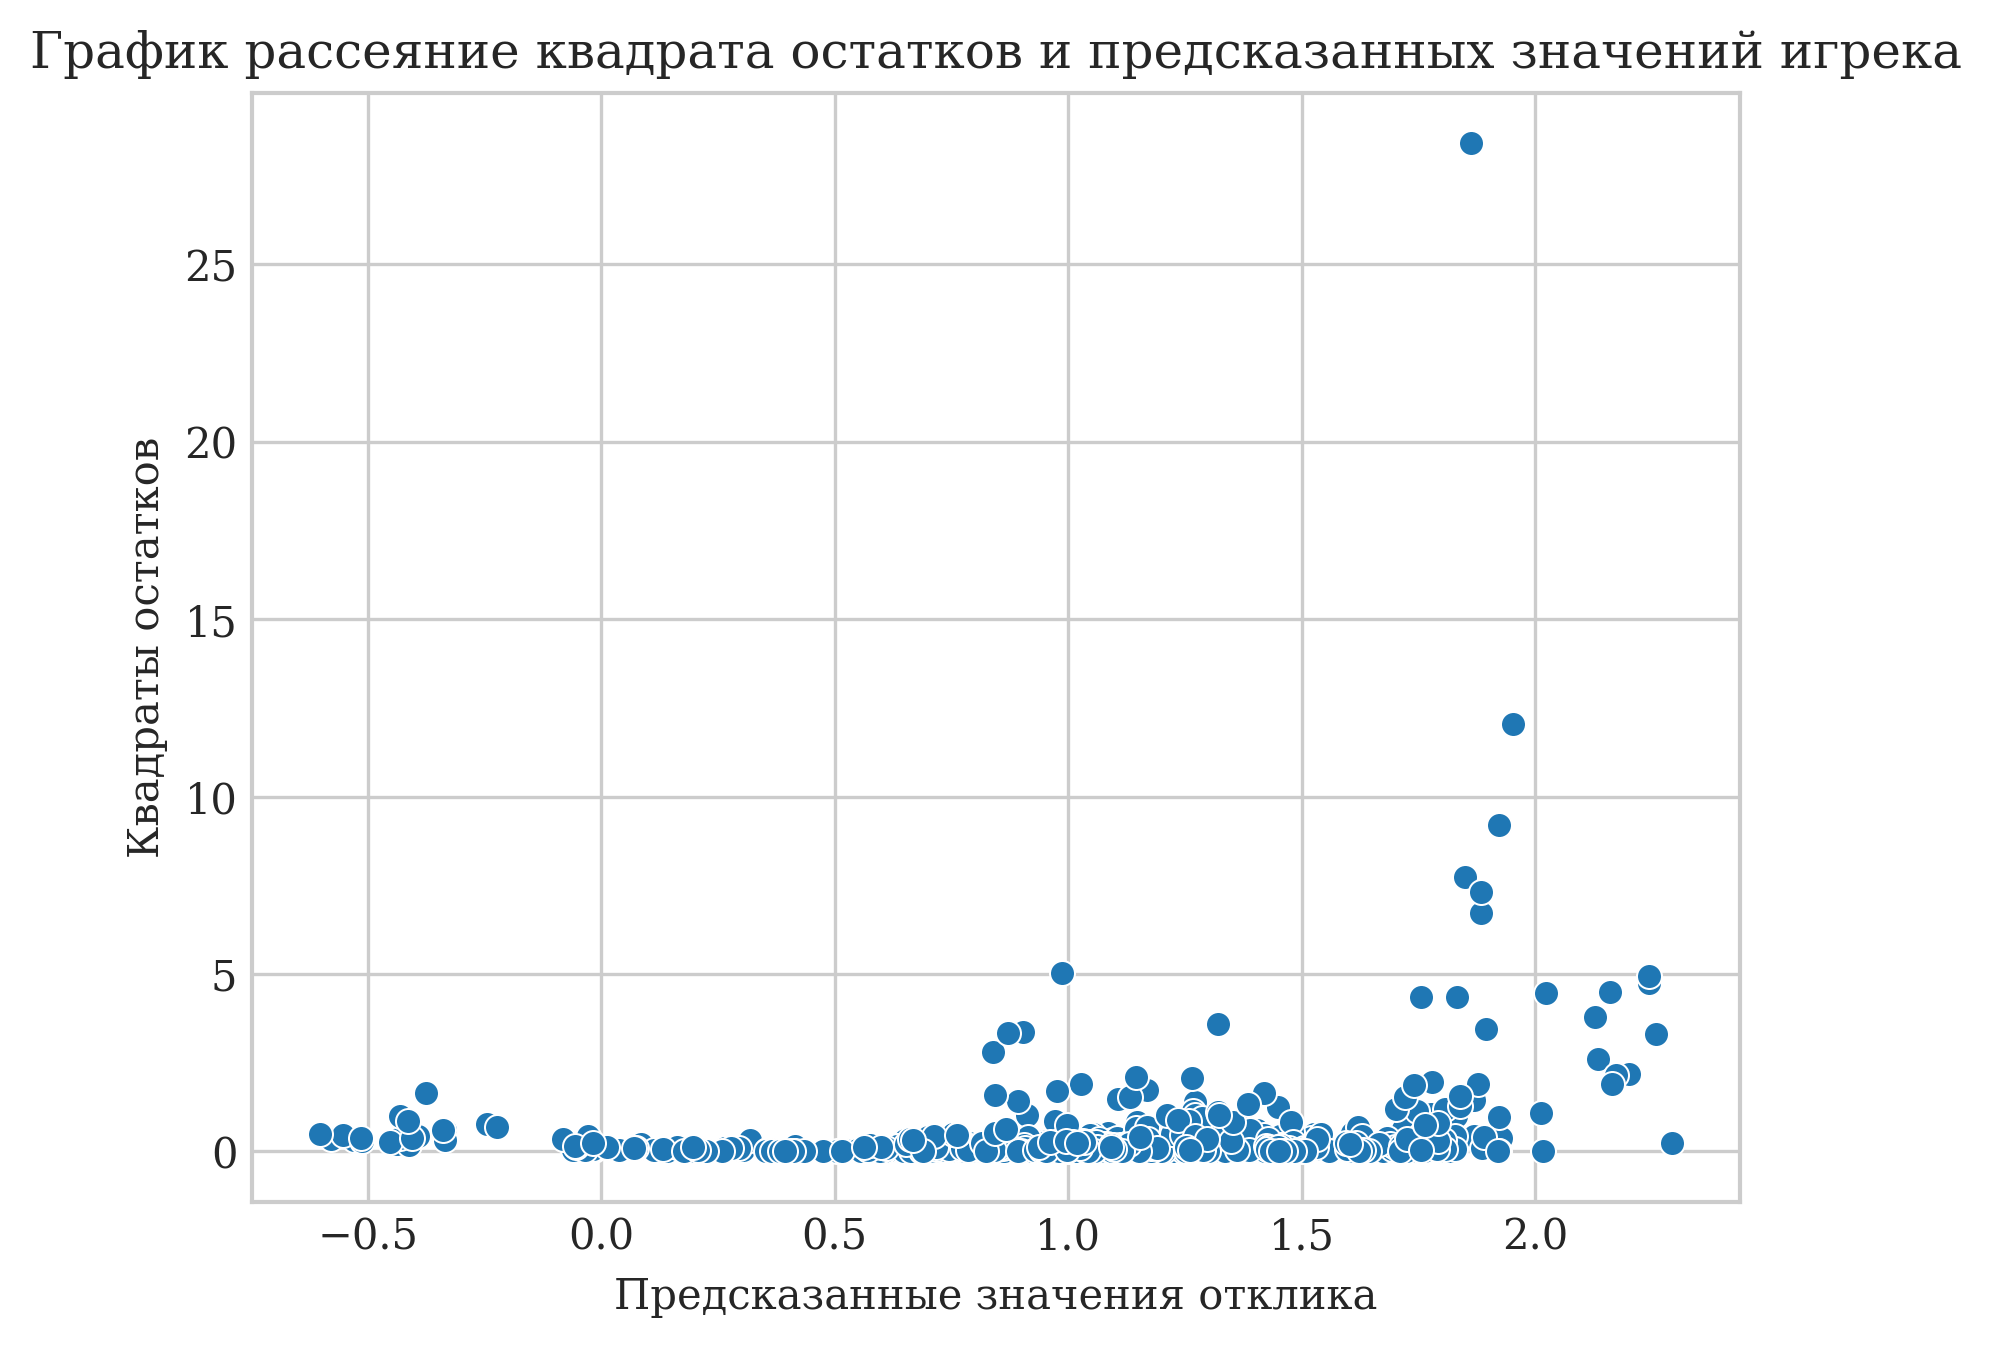

In [57]:
fitted = m_year_FE.predict()
residuals_sq = m_year_FE.resid**2
fig, ax = plt.subplots()

sns.scatterplot(x = fitted, y = residuals_sq)
ax.set_xlabel( "Предсказанные значения отклика")
ax.set_ylabel( "Квадраты остатков")
ax.set_title( "График рассеяние квадрата остатков и предсказанных значений игрека")

<a id="section-4-2"></a>
### 4.2  Автокорреляция

In [58]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

In [59]:
bg_test_1 = acorr_breusch_godfrey(m_pooled, nlags=1)

print(f'Statistic: {bg_test_1[0]:.3f}')
print(f'p-value: {bg_test_1[1]:.3f}')

Statistic: 262.400
p-value: 0.000


In [60]:
bg_test_1 = acorr_breusch_godfrey(m2_pooled, nlags=1)

print(f'Statistic: {bg_test_1[0]:.3f}')
print(f'p-value: {bg_test_1[1]:.3f}')

Statistic: 307.824
p-value: 0.000


In [61]:
bg_test_2 = acorr_breusch_godfrey(m_year_FE, nlags=1)

print(f'Statistic: {bg_test_2[0]:.3f}')
print(f'p-value: {bg_test_2[1]:.3f}')

Statistic: 264.757
p-value: 0.000


In [62]:
bg_test_2 = acorr_breusch_godfrey(m2_year_FE, nlags=1)

print(f'Statistic: {bg_test_2[0]:.3f}')
print(f'p-value: {bg_test_2[1]:.3f}')

Statistic: 307.670
p-value: 0.000


>**Комментарий.** Тесты свидетельствуют о наличии автокорреляции и гетероскедастичности, поэтому в моделях будут использоваться кластеризованные стандартные ошибки по регионам.